### Understanding and Reducing Missed GP Appointments: A Data-Driven Analysis of NHS Capacity and Resource Utilisation

**Background:**

The National Health Service (NHS) would like to understand and reduce the financial and operational impact of missed GP appointments across England. Recent reports suggest that some regions experience higher rates of missed appointments, uneven staff capacity, and under-utilised resources. These inefficiencies not only strain NHS budgets but also delay care for patients who need timely access.
The NHS needs a data-informed approach to decide how to reduce missed appointments and optimise current operations. This analysis hence focusses on understanding staff capacity, appointment utilisation, and potential drivers of missed appointments. The findings will help the NHS identify where improvements in planning, communication, or capacity management could deliver the greatest impact, both financially and socially.
The analysis focuses on KPIs that reflect appointment status and utilisation trends across regions, contexts, and service types. 

**Business questions:**
1. Has there been adequate staff and capacity in the networks?
2. What was the actual utilisation of resources?
3. How could we reduce missed appointments to optimise current operations?
   
**Analytical questions:**

The data is approached with the following questions to inform operational decisions on NHS capacity and allocation of resources:
1. Quantify appointment activity across regional and service setting to establish the baseline NHS utilisation in the networks.
2. Measure variation in appointment volumes over time to detect seasonal patterns that could indicate under or over-utilisation of NHS capacity.
3. Assess utilisation across healthcare professional types and service settings to identify care types that experience consistent pressure.
4. Calculate and compare Did Not Attend (DNA) rates across waiting periods and appointment modes to highlight factors that contribute to missed appointments, and to support targeted interventions and communication strategies.
5. Analyse public sentiment from Twitter data to uncover recurring themes about the NHS system that may influence attendance behaviour.

In [28]:
# Install missing packages
!pip install textblob wordcloud

# Import libraries 
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Text & sentiment analysis 
import re
import string
from textblob import TextBlob  
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
import nltk
nltk.download('vader_lexicon')

# Utility
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to C:\Users\Reshma
[nltk_data]     Pandit\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [30]:
# Define NHS colour palette for plots
NHS_PALETTE = {
    "nhs_blue": "#005EB8",
    "dark_blue": "#003087",
    "light_blue": "#41B6E6",
    "bright_blue": "#0072CE",
    "aqua_green": "#00A499",
    "dark_green": "#006747",
    "warm_yellow": "#FFB81C",
    "orange": "#ED8B00",
    "warm_red": "#DA291C",
    "pink": "#E46F9E",
    "purple": "#330072",
    "grey": "#A7A8AA"
}

# Create a list for Seaborn
NHS_COLORS = [
    NHS_PALETTE["nhs_blue"],
    NHS_PALETTE["bright_blue"],
    NHS_PALETTE["aqua_green"],
    NHS_PALETTE["warm_yellow"],
    NHS_PALETTE["warm_red"],
    NHS_PALETTE["purple"]
]

#  Create a seaborn colormap
nhs_heatmap_cmap = LinearSegmentedColormap.from_list(
    "NHS_Blues",
    [NHS_PALETTE["light_blue"], NHS_PALETTE["nhs_blue"], NHS_PALETTE["dark_blue"]]
)

In [3]:
# Define all the functions used in this analysis 
def validate_data(df):
    """
    Performs validation checks on a DataFrame:
    1. Counts unique values
    2. Displays summary statistics
    3. Checks for duplicates 
    4. Checks for null values
    5. Checks for potential outliers using the IQR method
    """
    # Counts unique values
    unique_counts = df.nunique()
    print("1.Unique values per column:")
    print(unique_counts)

    # Summary statistics
    summary_stats = df.describe()
    print("\n2.Summary statistics:")
    print(summary_stats)
    
    # Check for duplicates
    duplicate_count = df.duplicated().sum()
    print("\n3.Number of duplicate rows:")
    print(duplicate_count)
	  
    # Check for null values
    null_counts = df.isnull().sum()
    print("\n4.Missing values:")
    print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No missing values found.")
    print(null_counts)

    # Check for outliers in numeric columns using IQR method
    outlier_summary = {}
    numeric_cols = df.select_dtypes(include='number').columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)
    
    outlier_summary_series = pd.Series(outlier_summary)
    print("\n5. Potential Outliers (IQR method):")
    print(outlier_summary_series)
    print("\n")

def clean_text(s):
    """
    Clean a text value by stripping leading/trailing whitespace
    and converting to Proper Case (Title Case).
    Returns None if input is NaN or None.
    """ 
    if s is None or pd.isna(s):
        return None
    # Strip whitespace and convert to title case
    return str(s).strip().title()

def clean_label(text):
    """Clean and format labels for charts."""
    return str(text).replace('_', ' ')

def generate_standard_bar_chart(
    df,
    x,
    y,
    hue=None,
    title="Bar Chart",
    palette=NHS_COLORS,  # Use NHS palette by default
    figsize=(12, 6),
    rotate_xticks=45,
    legend_title=None,
    sort=False,
    ascending=False,
    **kwargs
):
    """
    Generate a standard bar chart with consistent styling.
    """
    # Clean labels
    x_label = clean_label(x)
    y_label = clean_label(y)
    legend_title = legend_title or clean_label(hue) if hue else None

    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=x, y=y, hue=hue, palette=palette, **kwargs)
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    if hue:
        plt.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc="upper left")

    if rotate_xticks:
        plt.xticks(rotation=rotate_xticks)
    
    plt.tight_layout()
    plt.show()

def generate_standard_line_plot(
    df,
    x,
    y,
    hue=None,
    title="Line Plot",
    palette=NHS_COLORS,  # Use NHS palette by default
    figsize=(12, 6),
    rotate_xticks=45,
    legend_title=None,
    marker="o",
    **kwargs
):
    """
    Generate a standard line plot with consistent styling.
    
    """
    # Clean labels
    x_label = clean_label(x)
    y_label = clean_label(y)
    legend_title = legend_title or clean_label(hue) if hue else None
   
    # Plot
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x, y=y, hue=hue, palette=palette, marker=marker, **kwargs)
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    if hue:
        plt.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc="upper left")

    if rotate_xticks:
        plt.xticks(rotation=rotate_xticks)
    
    plt.tight_layout()
    plt.show()

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"#", "", text)        # remove hashtag symbol
    text = re.sub(r"[^a-z\s]", "", text) # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

def extract_hashtags(text):
    if pd.isna(text):
        return []
    hashtags = re.findall(r"#\w+", text)
    return [h.lower() for h in hashtags]

In [4]:
# Load all datasets
ad = pd.read_csv('actual_duration.csv') # Load actual_duration.csv dataset as ad
ar = pd.read_csv('appointments_regional.csv') # Load appointments_regional.csv dataset as ar
nc = pd.read_excel('national_categories.xlsx') # Load national_categories.xlsx dataset as nc
tw = pd.read_csv('tweets.csv') # Load tweets.csv dataset as tw

# Keep an original copy for reference
ad_original = ad.copy()
ar_original = ar.copy()
nc_original = nc.copy()
tw_original = tw.copy()

### View, clean and validate the **ad** dataframe

In [5]:
# Inspect the ad dataframe
print(ad.shape)
ad.head()

(137793, 8)


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [9]:
# Check data types
ad.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [12]:
# Convert appointment_date to datetime
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'], errors='coerce')

ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   sub_icb_location_code      137793 non-null  object        
 1   sub_icb_location_ons_code  137793 non-null  object        
 2   sub_icb_location_name      137793 non-null  object        
 3   icb_ons_code               137793 non-null  object        
 4   region_ons_code            137793 non-null  object        
 5   appointment_date           137793 non-null  datetime64[ns]
 6   actual_duration            137793 non-null  object        
 7   count_of_appointments      137793 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 8.4+ MB


In [291]:
validate_data(ad)

1.Unique values per column:
sub_icb_location_code         106
sub_icb_location_ons_code     106
sub_icb_location_name         106
icb_ons_code                   42
region_ons_code                 7
appointment_date              212
actual_duration                 7
count_of_appointments        7611
dtype: int64

2.Summary statistics:
                    appointment_date  count_of_appointments
count                         137793          137793.000000
mean   2022-03-16 19:31:17.868977664            1219.080011
min              2021-12-01 00:00:00               1.000000
25%              2022-01-25 00:00:00             194.000000
50%              2022-03-16 00:00:00             696.000000
75%              2022-05-09 00:00:00            1621.000000
max              2022-06-30 00:00:00           15400.000000
std                              NaN            1546.902956

3.Number of duplicate rows:
0

4.Missing values:
No missing values found.
sub_icb_location_code        0
sub_icb_location_o

**Outliers in count_of_appointments:** 9,291 rows have unusually high appointment counts. These represent true anomalies and extremely busy locations rather than data errors, as reviewed below.

In [157]:
# View outlier rows in the data
Q1 = ad['count_of_appointments'].quantile(0.25)
Q3 = ad['count_of_appointments'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter to only outlier rows
outliers = ad[(ad['count_of_appointments'] < lower_bound) | (ad['count_of_appointments'] > upper_bound)]

# View a few examples
outliers.sort_values('count_of_appointments', ascending=False).head(5)

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
125518,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,17-Jan-22,Unknown / Data Quality,15400
125812,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,28-Feb-22,Unknown / Data Quality,15081
125861,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,07-Mar-22,Unknown / Data Quality,14767
126400,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,23-May-22,Unknown / Data Quality,14665
125616,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,31-Jan-22,Unknown / Data Quality,14664


Outlier Visualization:


<Figure size 1200x600 with 0 Axes>

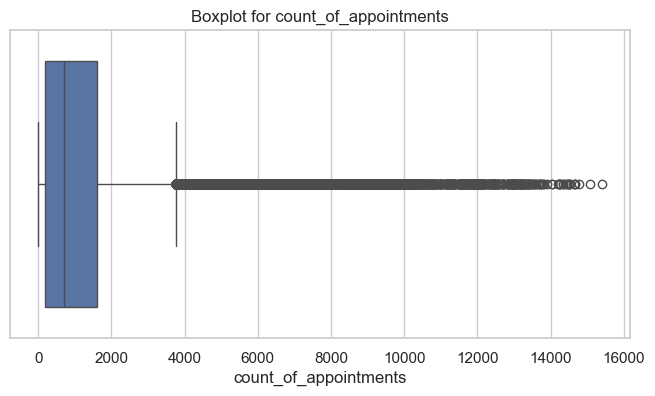

In [158]:
# View outliers using boxplot
print("Outlier Visualization:")
numeric_cols = ad.select_dtypes(include='number').columns

plt.figure(figsize=(12, 6))
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=ad[col])
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.show()

In [294]:
# Count outlier records per sub-ICB location 
outlier_counts = outliers['sub_icb_location_name'].value_counts()
print(outlier_counts.head(10))

sub_icb_location_name
NHS North West London ICB - W2U3Z              780
NHS Kent and Medway ICB - 91Q                  577
NHS Hampshire and Isle Of Wight ICB - D9Y0V    570
NHS North East London ICB - A3A8R              569
NHS Devon ICB - 15N                            566
NHS South East London ICB - 72Q                558
NHS South West London ICB - 36L                555
NHS Birmingham and Solihull ICB - 15E          522
NHS Black Country ICB - D2P2L                  491
NHS Norfolk and Waveney ICB - 26A              482
Name: count, dtype: int64


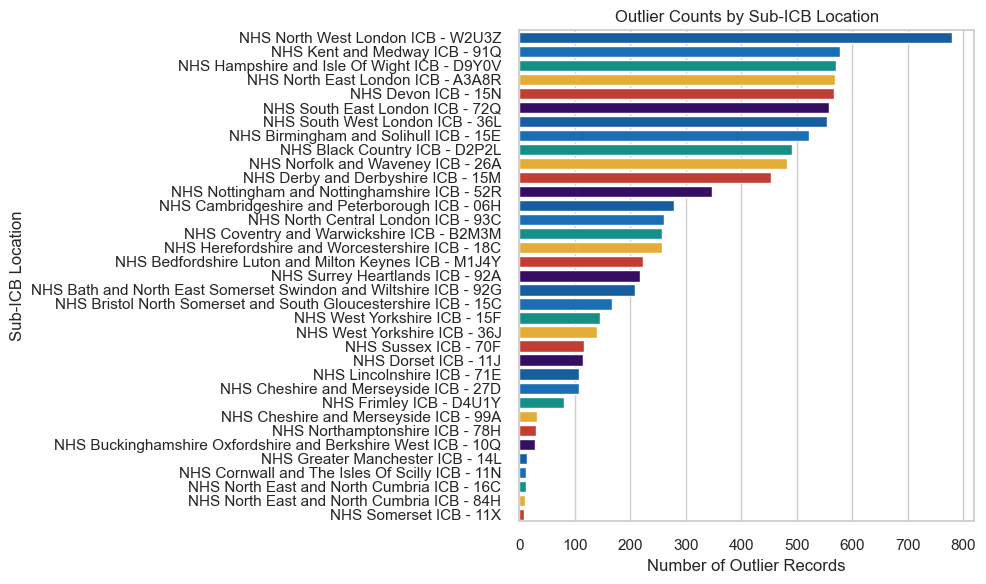

In [237]:
# Visualise outliers per sub-ICB location

plt.figure(figsize=(10, 6))
sns.barplot(
    x=outlier_counts.values,
    y=outlier_counts.index,
    palette=NHS_COLORS,
)
plt.title("Outlier Counts by Sub-ICB Location")
plt.xlabel("Number of Outlier Records")
plt.ylabel("Sub-ICB Location")
plt.tight_layout()
plt.show()

**Outliers in count_of_appointments:** This chart shows sub-ICB areas with unusually high appointment counts.  The unusually high appointment counts likely indicate extremely busy locations with high patient volumes, rather than representing data errors. 

In the absence of any data suggesting these could be errors, all outliers have been retained as they provide valuable insight into capacity and workload distribution across the NHS. 

In [82]:
# Check unique categories in key fields
print("Actual_duration:", ad["actual_duration"].unique())

Actual_duration: ['31-60 Minutes' '21-30 Minutes' '6-10 Minutes' 'Unknown / Data Quality'
 '16-20 Minutes' '11-15 Minutes' '1-5 Minutes']


In [259]:
# Check percentage of unknown records
unknown_records = ad[ad['actual_duration'] == 'Unknown / Data Quality'].shape[0]
total_records = ad.shape[0]
unknown_percentage_records = (unknown_records / total_records * 100)

# Check if unknown records cluster in specific locations 
unknown_subset = ad[ad['actual_duration'] == 'Unknown / Data Quality']
total_locations = ad['sub_icb_location_name'].nunique()
locations_with_unknown = unknown_subset['sub_icb_location_name'].nunique()

print(f"Total records: {total_records:,}")
print(f"Unknown/Data Quality records: {unknown_records:,}")
print(f"Percentage of records: {unknown_percentage_records:.2f}%")
print(f"Locations with unknown values: {locations_with_unknown} out of {total_locations} total locations")
print(f"Percentage of locations affected: {(locations_with_unknown/total_locations*100):.2f}%")

Total records: 137,793
Unknown/Data Quality records: 20,161
Percentage of records: 14.63%
Locations with unknown values: 106 out of 106 total locations
Percentage of locations affected: 100.00%


**Unknown/Data Quality records:** As 14.63% of "actual_duration" records have unknown duration and all 106 locations are affected, this seems to be a systemic data infrastructure issue and hence these values are not removed from the dataset.

In [295]:
# Record counts & date range of the ad dataset
n_records = len(ad)
date_min, date_max = ad["appointment_date"].min(), ad["appointment_date"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

Number of records: 137,793
Date range: 2021-12-01 to 2022-06-30


In [13]:
# Extract date parts
ad['year'] = ad['appointment_date'].dt.year
ad['month'] = ad['appointment_date'].dt.month
ad['day'] = ad['appointment_date'].dt.day
ad['day_of_week'] = ad['appointment_date'].dt.day_name()

# Create a month-year column
ad['month_year'] = ad['appointment_date'].dt.to_period('M').astype(str)

ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,year,month,day,day_of_week,month_year
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,2021,12,1,Wednesday,2021-12
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,2021,12,1,Wednesday,2021-12
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,2021,12,1,Wednesday,2021-12
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,2021,12,1,Wednesday,2021-12
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,2021,12,1,Wednesday,2021-12


### View, clean and validate the **ar** dataframe

In [106]:
# Inspect the ar dataframe
print(ar.shape)
ar.head()

(596821, 9)


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,year,month
0,E54000034,2020-01-01,Attended,Gp,Face-To-Face,1 Day,8107,2020,1
1,E54000034,2020-01-01,Attended,Gp,Face-To-Face,15 to 21 Days,6791,2020,1
2,E54000034,2020-01-01,Attended,Gp,Face-To-Face,2 to 7 Days,20686,2020,1
3,E54000034,2020-01-01,Attended,Gp,Face-To-Face,22 to 28 Days,4268,2020,1
4,E54000034,2020-01-01,Attended,Gp,Face-To-Face,8 to 14 Days,11971,2020,1


In [159]:
# Check data types
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [105]:
# Convert appointment_month to datetime
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'], errors='coerce')

ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 9 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   icb_ons_code                       596821 non-null  object        
 1   appointment_month                  596821 non-null  datetime64[ns]
 2   appointment_status                 596821 non-null  object        
 3   hcp_type                           596821 non-null  object        
 4   appointment_mode                   596821 non-null  object        
 5   time_between_book_and_appointment  596821 non-null  object        
 6   count_of_appointments              596821 non-null  int64         
 7   year                               596821 non-null  int32         
 8   month                              596821 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(5)
memory usage: 36.4+ MB


In [109]:
# Choose columns you want to clean
text_cols = ["appointment_status", "hcp_type", "appointment_mode"]

for col in text_cols:
    ar[col] = ar[col].map(clean_text)

In [22]:
validate_data(ar)

1.Unique values per column:
icb_ons_code                            42
appointment_month                       30
appointment_status                       3
hcp_type                                 3
appointment_mode                         5
time_between_book_and_appointment        8
count_of_appointments                22807
dtype: int64

2.Summary statistics:
                   appointment_month  count_of_appointments
count                         596821          596821.000000
mean   2021-03-19 11:31:17.489565696            1244.601857
min              2020-01-01 00:00:00               1.000000
25%              2020-08-01 00:00:00               7.000000
50%              2021-04-01 00:00:00              47.000000
75%              2021-11-01 00:00:00             308.000000
max              2022-06-01 00:00:00          211265.000000
std                              NaN            5856.887042

3.Number of duplicate rows:
21604

4.Missing values:
No missing values found.
icb_ons_code    

**Duplicate rows:** The identified duplicate rows (21604 records) do not appear to be data errors. Since the dataset contains only categorical variables without unique identifiers , multiple rows with identical combinations likely represent legitimate aggregated data for the same category combinations. 

**Outliers in Count of Appointments:** Consitent with patterns observed in the actual_duration dataset, the unusually high appointment counts likely indicate extremely busy locations with high patient volumes, rather than representing data errors. 

In absence of any data suggesting these could be errors, all outliers have been retained as they provide valuable insight into capacity and workload distribution across the NHS. 

In [23]:
# Unique categories in key fields
print("Appointment_status:", ar["appointment_status"].unique())
print("HCP_type:", ar["hcp_type"].unique())
print("Appointment_mode:", ar["appointment_mode"].unique())
print("Time_between_book_and_appointment:", ar["time_between_book_and_appointment"].unique())

Appointment_status: ['Attended' 'Dna' 'Unknown']
HCP_type: ['Gp' 'Other Practice Staff' 'Unknown']
Appointment_mode: ['Face-To-Face' 'Home Visit' 'Telephone' 'Unknown' 'Video/Online']
Time_between_book_and_appointment: ['1 Day' '15  to 21 Days' '2 to 7 Days' '22  to 28 Days' '8  to 14 Days'
 'More than 28 Days' 'Same Day' 'Unknown / Data Quality']


In [32]:
# Check percentage of unknown records for appointment status
unknown_records_appointment_status = ar[ar['appointment_status'] == 'Unknown'].shape[0]
total_records = ar.shape[0]
unknown_percentage_records = (unknown_records_appointment_status / total_records * 100)

# Check if unknown records cluster in specific locations 
unknown_subset = ar[ar['appointment_status'] == 'Unknown']
total_locations = ar['icb_ons_code'].nunique()
locations_with_unknown = unknown_subset['icb_ons_code'].nunique()

print(f"Total records: {total_records:,}")
print(f"Unknown/Data Quality records: {unknown_records_appointment_status:,}")
print(f"Percentage of records: {unknown_percentage_records:.2f}%")
print(f"Locations with unknown values: {locations_with_unknown} out of {total_locations} total locations")
print(f"Percentage of locations affected: {(locations_with_unknown/total_locations*100):.2f}%")

Total records: 596,821
Unknown/Data Quality records: 201,324
Percentage of records: 33.73%
Locations with unknown values: 42 out of 42 total locations
Percentage of locations affected: 100.00%


**Data quality:** Consistent with data quality patterns observed in the actual_duration, the unknown/data quality records are high in number and appear to be a systemic data infrastructure challenges. Hence these values are retained in the dataset. 

In [29]:
# Record counts & date range
n_records = len(ar)
date_min, date_max = ar["appointment_month"].min(), ar["appointment_month"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

Number of records: 596,821
Date range: 2020-01-01 to 2022-06-01


In [30]:
# Extract date parts
ar['year'] = ar['appointment_month'].dt.year
ar['month'] = ar['appointment_month'].dt.month

ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,year,month
0,E54000034,2020-01-01,Attended,Gp,Face-To-Face,1 Day,8107,2020,1
1,E54000034,2020-01-01,Attended,Gp,Face-To-Face,15 to 21 Days,6791,2020,1
2,E54000034,2020-01-01,Attended,Gp,Face-To-Face,2 to 7 Days,20686,2020,1
3,E54000034,2020-01-01,Attended,Gp,Face-To-Face,22 to 28 Days,4268,2020,1
4,E54000034,2020-01-01,Attended,Gp,Face-To-Face,8 to 14 Days,11971,2020,1


### View, clean and validate the **nc** dataframe

In [111]:
# Inspect the nc dataframe
print(nc.shape)
nc.head()

(817394, 12)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year,month,day,day_of_week
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient Contact During Care Home Round,3,2021-08-01,2021,8,2,Monday
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,2021,8,2,Monday
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,2021,8,2,Monday
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,2021,8,2,Monday
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,2021,8,2,Monday


In [160]:
# Check data types
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [64]:
# Convert appointment_date to datetime
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'], errors='coerce')

nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  datetime64[ns]
 8   year                   817394 non-null  int32         
 9   month                  817394 non-null  int32         
 10  day                    817394 non-null  int32         
 11  day_of_week            817394 non-null  object        
dtypes: datetime64[ns](2), int32(3), int64(1), ob

In [38]:
# Choose columns you want to clean
text_cols = ["service_setting", "context_type", "national_category"]

for col in text_cols:
    nc[col] = nc[col].map(clean_text)

In [112]:
validate_data(nc)

1.Unique values per column:
appointment_date          334
icb_ons_code               42
sub_icb_location_name     106
service_setting             5
context_type                3
national_category          18
count_of_appointments    9957
appointment_month          11
year                        2
month                      11
day                        31
day_of_week                 7
dtype: int64

2.Summary statistics:
                    appointment_date  count_of_appointments  \
count                         817394          817394.000000   
mean   2022-01-16 00:50:35.860796160             362.183684   
min              2021-08-01 00:00:00               1.000000   
25%              2021-10-25 00:00:00               7.000000   
50%              2022-01-18 00:00:00              25.000000   
75%              2022-04-07 00:00:00             128.000000   
max              2022-06-30 00:00:00           16590.000000   
std                              NaN            1084.576600   

        

**Outliers of count_of_appointments:** Consistent with data quality patterns observed in the actual_duration and appointments_regional datasets, the unusually high appointment counts likely indicate extremely busy locations with high patient volumes, rather than representing data errors. 

In absence of any data suggesting that these could be errors, all outliers have been retained. 

In [41]:
# Unique categories in key fields
print("Service_setting:", nc["service_setting"].unique())
print("Context_type:", nc["context_type"].unique())
print("National_category:", nc["national_category"].unique())

Service_setting: ['Primary Care Network' 'Other' 'General Practice' 'Unmapped'
 'Extended Access Provision']
Context_type: ['Care Related Encounter' 'Unmapped' 'Inconsistent Mapping']
National_category: ['Patient Contact During Care Home Round' 'Planned Clinics' 'Home Visit'
 'General Consultation Acute' 'Structured Medication Review'
 'Care Home Visit' 'Unmapped' 'Clinical Triage'
 'Planned Clinical Procedure' 'Inconsistent Mapping'
 'Care Home Needs Assessment & Personalised Care And Support Planning'
 'General Consultation Routine'
 'Service Provided By Organisation External To The Practice'
 'Unplanned Clinical Activity' 'Social Prescribing Service'
 'Non-Contractual Chargeable Work'
 'Group Consultation And Group Education' 'Walk-In']


**Data quality:** Consistent with data quality patterns observed in the actual_duration and appointment_regional datasets, these unmapped values represent systemic data infrastructure challenges rather than isolated errors and have been retained.

In [42]:
# Record counts & date range
n_records = len(nc)
date_min, date_max = nc["appointment_date"].min(), nc["appointment_date"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

Number of records: 817,394
Date range: 2021-08-01 to 2022-06-30


In [43]:
# Extract date parts
nc['year'] = nc['appointment_date'].dt.year
nc['month'] = nc['appointment_date'].dt.month
nc['day'] = nc['appointment_date'].dt.day
nc['day_of_week'] = nc['appointment_date'].dt.day_name()

nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,year,month,day,day_of_week
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient Contact During Care Home Round,3,2021-08-01,2021,8,2,Monday
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,2021,8,2,Monday
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,2021,8,2,Monday
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,2021,8,2,Monday
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,2021,8,2,Monday


### View, clean and validate the **tw** dataframe

In [113]:
# Inspect the tw dataset
print(tw.shape)
tw.head()

(1174, 10)


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,As Arkansas’ First Comprehensive Stroke Certif...,"{'Hashtags': [{'Text': 'Healthcare', 'Indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1,1567582846612553728,Rt @Andreagrammer: Work-Life Balance Is At The...,"{'Hashtags': [{'Text': 'Premisehealth', 'Indic...","#Premisehealth, #Hiring","{'iso_language_code': 'en', 'result_type': 're...",2,0,False,False,en
2,1567582787070304256,Rt @Ontariogreens: $10 Billion Can Go A Long W...,"{'Hashtags': [{'Text': 'Healthcare', 'Indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",39,0,False,False,en
3,1567582767625428992,Rt @Modrnhealthcr: 🚨#New:🚨 Insurance Companies...,"{'Hashtags': [{'Text': 'New', 'Indices': [20, ...",#New,"{'iso_language_code': 'en', 'result_type': 're...",5,0,False,False,en
4,1567582720460570625,Icymi: Our Recent Blogs On Cybersecurity In Ac...,"{'Hashtags': [{'Text': 'Blogs', 'Indices': [18...","#Blogs, #Digitaltransformation, #Cybersecurity...","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en


In [47]:
tw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


In [48]:
# Choose columns you want to clean
text_cols = ["tweet_full_text", "tweet_entities", "tweet_entities_hashtags"]

for col in text_cols:
    tw[col] = tw[col].map(clean_text)

In [49]:
validate_data(tw)

1.Unique values per column:
tweet_id                   1174
tweet_full_text             961
tweet_entities              945
tweet_entities_hashtags     705
tweet_metadata                1
tweet_retweet_count          47
tweet_favorite_count         20
tweet_favorited               1
tweet_retweeted               1
tweet_lang                    1
dtype: int64

2.Summary statistics:
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std    2.427553e+13            29.784675               2.04470
min    1.567574e+18             0.000000               0.00000
25%    1.567590e+18             0.000000               0.00000
50%    1.567611e+18             1.000000               0.00000
75%    1.567633e+18             3.000000               0.00000
max    1.567655e+18           303.000000              42.00000

3.Number of duplicate rows:
0

4.Missing values:

In [60]:
# Check format of existing hashtags
sample_non_null = tw[tw['tweet_entities_hashtags'].notnull()]['tweet_entities_hashtags'].iloc[0] if tw['tweet_entities_hashtags'].notnull().any() else None

if sample_non_null is not None:
    print(f"Sample non-null value: {sample_non_null}")
    print(f"Type: {type(sample_non_null)}")
    print()

# Fill nulls with empty string
tw['tweet_entities_hashtags'] = tw['tweet_entities_hashtags'].fillna('')
print("✓ Detected string format → Filled nulls with empty string ''")

print(f"Null values remaining: {tw['tweet_entities_hashtags'].isnull().sum()}")

Sample non-null value: #Healthcare
Type: <class 'str'>

✓ Detected string format → Filled nulls with empty string ''
Null values remaining: 0


**Null values in tweet_entities_hashtags:** While it is common to see tweets without any hashtags, the null have been filled with empty strings to allow further analysis.

**Data cleaning and validation is complete, and data is ready to use for analysis.**

## Exploratory Data Analysis (EDA)

In [168]:
# Configure visuals
plt.style.use('seaborn-v0_8')
sns.set_theme()

In [163]:
# Calculate the number of locations
print("nc locations_sub_icb:", nc["sub_icb_location_name"].nunique())
print("ar locations_icb:", ar["icb_ons_code"].nunique())
print("ad locations_sub_icb:", ad["sub_icb_location_name"].nunique())

nc locations_sub_icb: 106
ar locations_icb: 42
ad locations_sub_icb: 106


In [164]:
# Verify locations across datasets
set(nc["sub_icb_location_name"]) == set(ad["sub_icb_location_name"])

True

The above line confirms that both nc and ad dataframes cover the same locations.

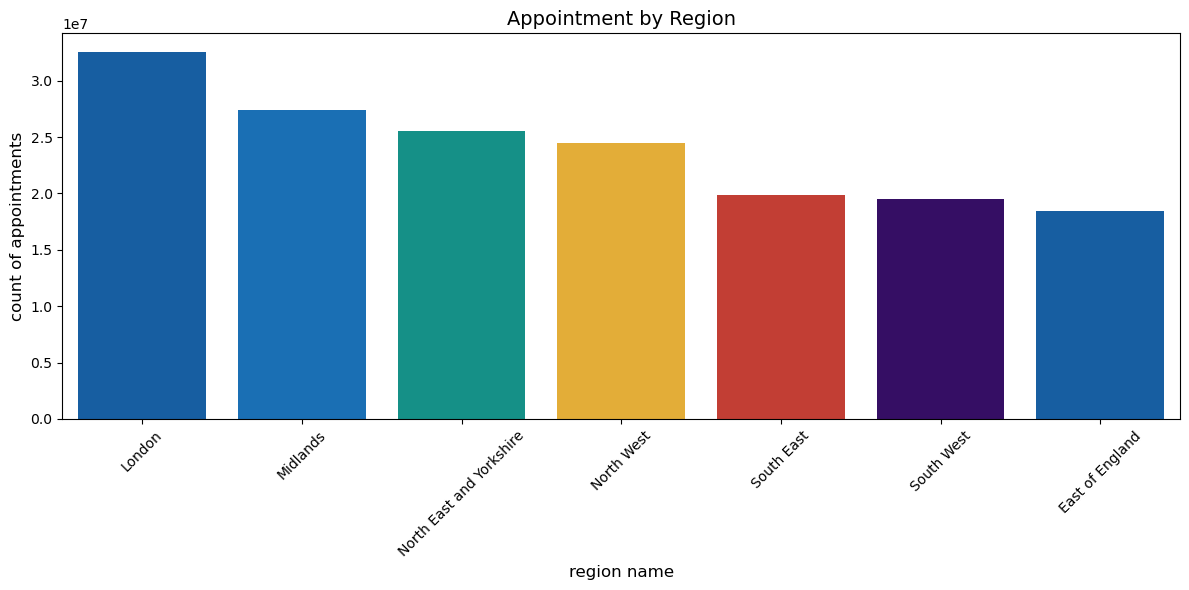

In [31]:
# Visualise number of appointments across regions

# Dictionary mapping region_ons_code to readable names
region_name_map = {
    "E40000011": "London",
    "E40000012": "Midlands",
    "E40000005": "North East and Yorkshire",
    "E40000003": "North West",
    "E40000010": "South East",
    "E40000007": "South West",
    "E40000006": "East of England"
}

# Apply mapping
ad['region_name'] = ad['region_ons_code'].map(region_name_map)

# Group by region name
region_summary_named = (
    ad.groupby('region_name', as_index=False)['count_of_appointments']
    .sum()
    .sort_values(by='count_of_appointments', ascending=False)
)

generate_standard_bar_chart(
    df=region_summary_named,
    x="region_name",
    y="count_of_appointments",
    title="Appointment by Region",
    sort=False
)

London is the busiest NHS location in England.

In [137]:
# Five locations with the highest number of appointments
top_locations = ad.groupby('sub_icb_location_name')['count_of_appointments'].sum().sort_values(ascending=False)
print(top_locations.head())

sub_icb_location_name
NHS North West London ICB - W2U3Z              6976986
NHS North East London ICB - A3A8R              5341883
NHS Kent and Medway ICB - 91Q                  5209641
NHS Hampshire and Isle Of Wight ICB - D9Y0V    4712737
NHS South East London ICB - 72Q                4360079
Name: count_of_appointments, dtype: int64


Three sub-ICBs in London are in the top 5 locations with highest number of appointments, reflecting the high demand in cities. Operational improvements in these sub-ICBs could potentially have a high operational impact.

In [139]:
# Determine the number of service settings.
print("Number of service settings:", nc["service_setting"].nunique())
print("Number of service settings:", nc["service_setting"].value_counts())

Number of service settings: 5
Number of service settings: service_setting
General Practice             359274
Primary Care Network         183790
Other                        138789
Extended Access Provision    108122
Unmapped                      27419
Name: count, dtype: int64


General Practice is the busiest service setting by a large margin.

In [78]:
# Determine the number of context types.
print("Number of context types:", nc["context_type"].nunique())
print("Context types:", nc["context_type"].value_counts())

Number of context types: 3
Context types: context_type
Care Related Encounter    700481
Inconsistent Mapping       89494
Unmapped                   27419
Name: count, dtype: int64


Care Related Encounter are the dominant and clearly documented context type, improvement in data collection practices can help better understand this distribution.

In [79]:
# Determine the number of national categories.
print("Number of national categories:", nc["national_category"].nunique())
print("National categories:", nc["national_category"].value_counts())

Number of national categories: 18
National categories: national_category
Inconsistent Mapping                                                   89494
General Consultation Routine                                           89329
General Consultation Acute                                             84874
Planned Clinics                                                        76429
Clinical Triage                                                        74539
Planned Clinical Procedure                                             59631
Structured Medication Review                                           44467
Service Provided By Organisation External To The Practice              43095
Home Visit                                                             41850
Unplanned Clinical Activity                                            40415
Patient Contact During Care Home Round                                 28795
Unmapped                                                               27419
Car

General Consultation (Routine and Acute) are the most commonly accessed national categories. A large amount data is inconsitently mapped, improvement in data collection practices can help better understand this distribution.

In [202]:
# Determine the number of appointment statuses.
print("Number of appointment_statuses:", ar["appointment_status"].nunique())
print("Appointment_statuses:", ar["appointment_status"].value_counts())

# Group by appointment_status and calculate aggregates
ar_summary = (
    ar.groupby("appointment_status")
      .agg(
          total_appointments=("count_of_appointments", "sum"),
          record_count=("count_of_appointments", "count")
      )
      .reset_index()
      .sort_values(by="total_appointments", ascending=False)
)

# Add a percentage column
ar_summary["percent_of_total"] = (
    ar_summary["total_appointments"] / ar_summary["total_appointments"].sum() * 100
).round(2)

# Display summary table
print(ar_summary)

Number of appointment_statuses: 3
Appointment_statuses: appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64
  appointment_status  total_appointments  record_count  percent_of_total
0           Attended           677755876        232137             91.24
2            Unknown            34137416        201324              4.60
1                DNA            30911233        163360              4.16


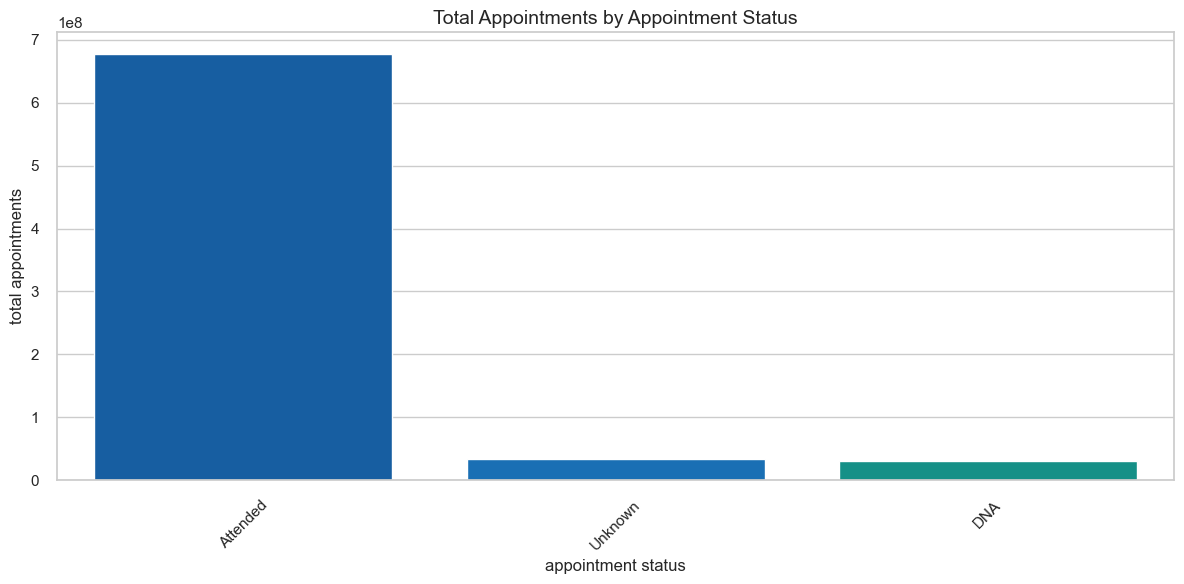

In [227]:
generate_standard_bar_chart(
    df=ar_summary,
    x="appointment_status",
    y="total_appointments",
    title="Total Appointments by Appointment Status",
    sort=False
)

**Reducing missed appointments could recover resources lost in approximately 4% (30911233 appointments) of all scheduled appointments.**

In [172]:
# Visualise distribution of appointment status and mode 

# Group by appointment status and appointment mode
ar_mode_summary = (
    ar.groupby(["appointment_status", "appointment_mode"])["count_of_appointments"]
      .sum()
      .reset_index()
)

# Calculate total per appointment_status for percentage calculation
status_totals = ar_mode_summary.groupby("appointment_status")["count_of_appointments"].transform("sum")

# Add percentage column
ar_mode_summary["percent_within_status"] = (
    ar_mode_summary["count_of_appointments"] / status_totals * 100
).round(2)

# Sort for readability
ar_mode_summary = ar_mode_summary.sort_values(
    by=["appointment_status", "count_of_appointments"], ascending=[True, False]
)

print(ar_mode_summary.head(10))

  appointment_status appointment_mode  count_of_appointments  \
0           Attended     Face-to-Face              392705999   
2           Attended        Telephone              254799226   
3           Attended          Unknown               23335350   
1           Attended       Home Visit                3612068   
4           Attended     Video/Online                3303233   
5                DNA     Face-to-Face               24253038   
7                DNA        Telephone                5262251   
8                DNA          Unknown                1049427   
6                DNA       Home Visit                 187571   
9                DNA     Video/Online                 158946   

   percent_within_status  
0                  57.94  
2                  37.59  
3                   3.44  
1                   0.53  
4                   0.49  
5                  78.46  
7                  17.02  
8                   3.39  
6                   0.61  
9                   0.51 

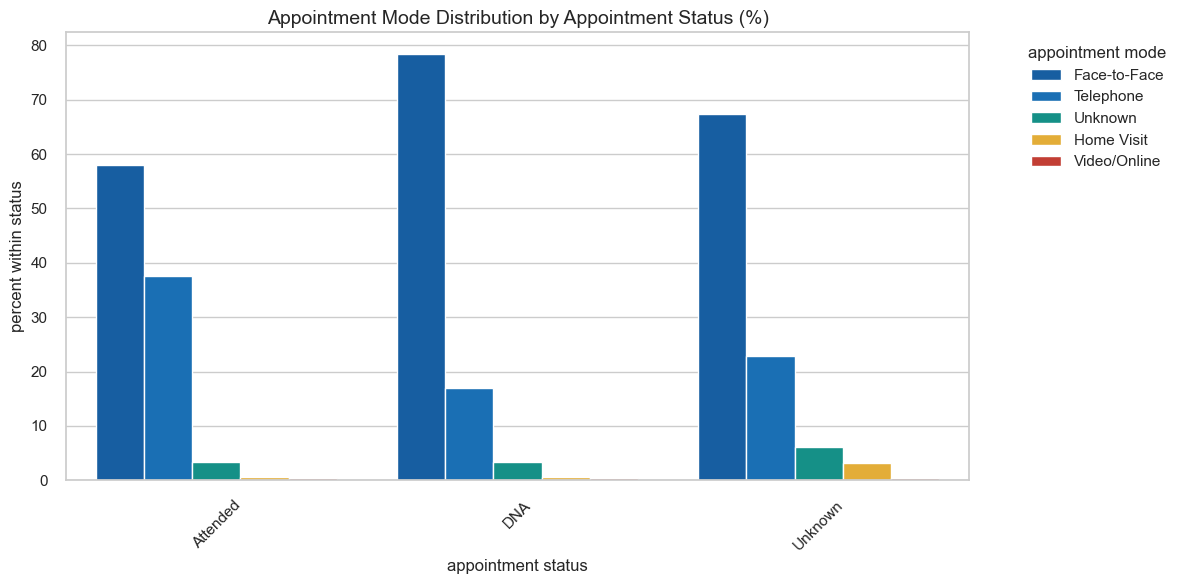

In [245]:
# Visualise using a bar chart 

generate_standard_bar_chart(
    df=ar_mode_summary,
    x="appointment_status",
    y="percent_within_status",
    hue="appointment_mode",
    title="Appointment Mode Distribution by Appointment Status (%)",
    sort=False
)

**Face to face appointments** are the highest share of appointments across all appointment statuses.

In [138]:
# Determine the number of hcp_types
print("Number of HCP type:", ar["hcp_type"].nunique())
print("HCP type:", ar["hcp_type"].value_counts())

Number of HCP type: 3
HCP type: hcp_type
Other Practice staff    241557
GP                      226036
Unknown                 129228
Name: count, dtype: int64


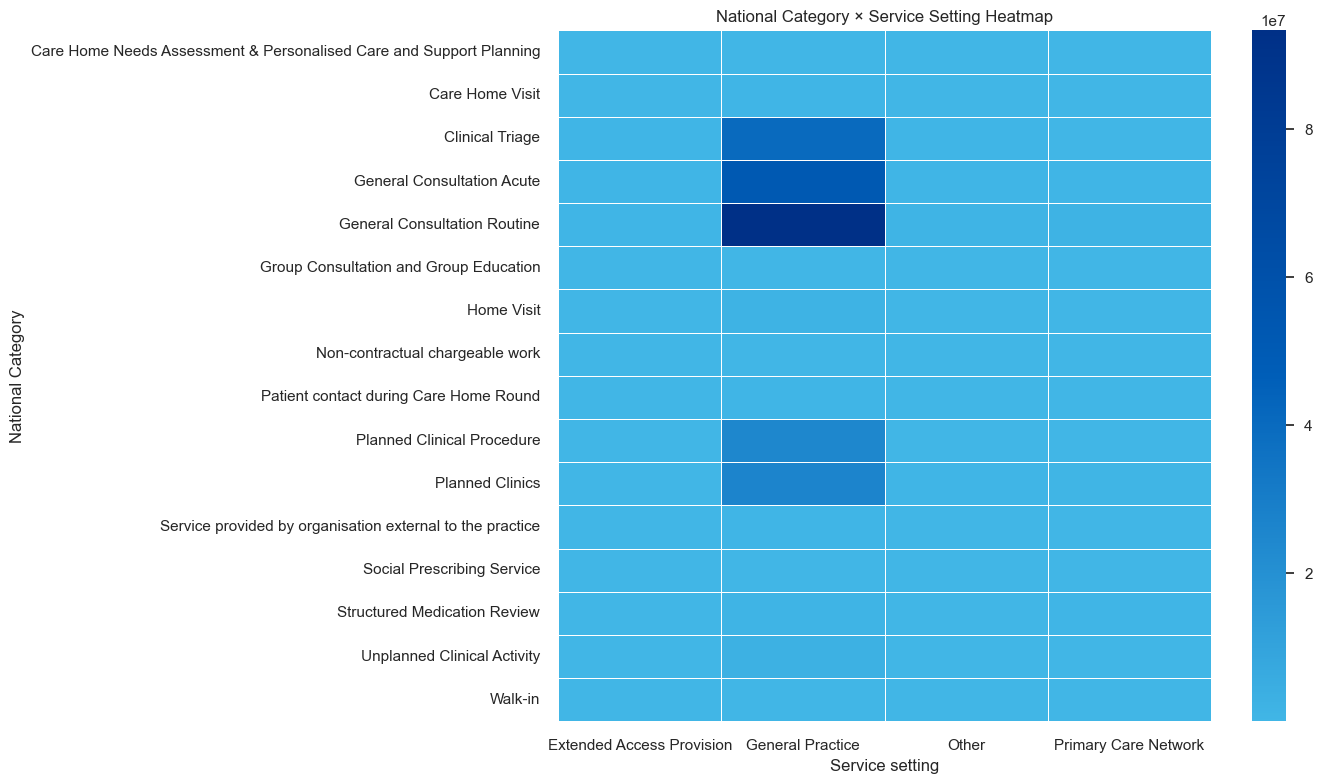

In [254]:
# Visualise distribution across national categories and service settings 

# Filter out attended and unknown statuses
filtered_nc = nc[
    (nc["national_category"] != "Inconsistent Mapping") &
    (nc["national_category"] != "Unmapped")
]

# Group by appointment mode and waiting time, summing total appointments
pivot_heatmap = (
    filtered_nc.groupby(["national_category", "service_setting"])["count_of_appointments"]
    .sum()
    .reset_index()
    .pivot_table(
        index="national_category",
        columns="service_setting",
        values="count_of_appointments",
        fill_value=0
    )
)

# Plot the heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot_heatmap,
    cmap=nhs_heatmap_cmap,
    linewidths=0.5,

)
plt.title("National Category × Service Setting Heatmap")
plt.xlabel("Service setting")
plt.ylabel("National Category")
plt.tight_layout()
plt.show()

Between **2021-08-01 to 2022-06-30, General practice** shows the highest number of appointments across all service settings, with **general consultation (routine and acute), clinical triage and planned clinical procedures and clinics** driving the majority of appointments.

In [173]:
# Visualise DNA appointment status across appointment mode and waiting time 

# Check unique values to re-order columns for visualisation
print("time_between_book_and_appointment:", ar["time_between_book_and_appointment"].unique())

time_between_book_and_appointment: ['1 Day' '15  to 21 Days' '2 to 7 Days' '22  to 28 Days' '8  to 14 Days'
 'More than 28 Days' 'Same Day' 'Unknown / Data Quality']


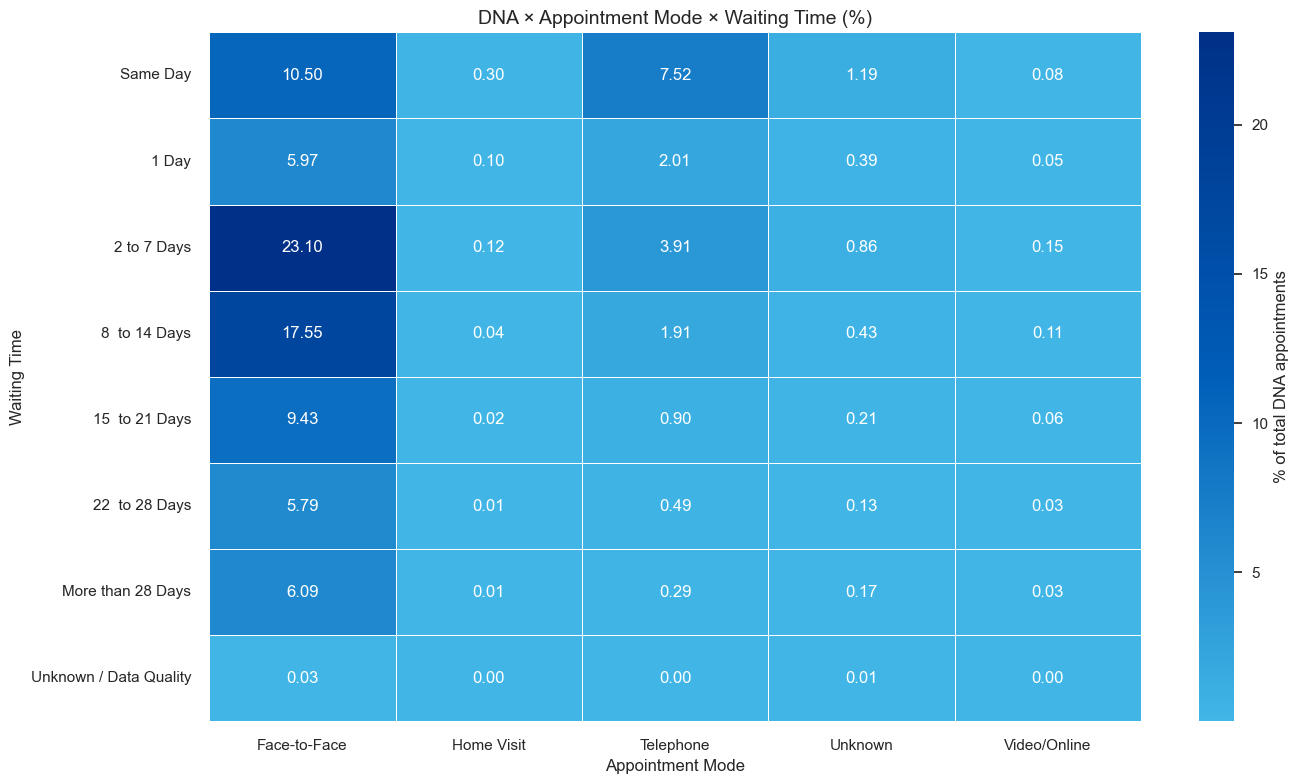

In [174]:
# Define the order for waiting time
time_between_book_and_appointment_order = [
    "Same Day",
    "1 Day",
    "2 to 7 Days",
    "8  to 14 Days",
    "15  to 21 Days",
    "22  to 28 Days",
    "More than 28 Days",
    "Unknown / Data Quality"
]

# Filter out attended and unknown statuses
filtered = ar[
    (ar["appointment_status"] != "Attended") &
    (ar["appointment_status"] != "Unknown")
]

# Group by appointment mode and waiting time, summing total appointments
pivot_heatmap1 = (
    filtered.groupby(["appointment_mode", "time_between_book_and_appointment"])["count_of_appointments"]
    .sum()
    .reset_index()
    .pivot_table(
        index="time_between_book_and_appointment",
        columns="appointment_mode",
        values="count_of_appointments",
        fill_value=0
    )
)

# Reindex rows to ensure correct sequential order
pivot_heatmap1 = pivot_heatmap1.reindex(time_between_book_and_appointment_order)

# Convert to percentage of total DNA appointments
pivot_heatmap_percent = (pivot_heatmap1 / pivot_heatmap1.sum().sum()) * 100

# Plot the heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot_heatmap_percent,
    cmap=nhs_heatmap_cmap,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={'label': '% of total DNA appointments'}
)
plt.title("DNA × Appointment Mode × Waiting Time (%)", fontsize=14)
plt.xlabel("Appointment Mode", fontsize=12)
plt.ylabel("Waiting Time", fontsize=12)
plt.tight_layout()
plt.show()

**Between 2020-01-01 to 2022-06-01:**

1. Face-to-face appointments account for the majority of missed appointments, suggesting that traditional appointment modes faced significant non-attendance challenges during this period.

2. Same-day face-to-face and telephonic appointments show a slightly higher rate of missed attendance compared to those with longer waiting periods, possibly due to short notice or competing priorities.

3. Video/online appointments and home visits have lower non-attendance rates, indicating that greater flexibility and reduced travel requirements improve attendance.

4. Appointments with more than seven days of notice are more likely to be attended, suggesting that adequate booking lead time supports better patient planning and commitment.

#### **Record counts & date range**

In [ ]:
# Record counts & date range of the ad dataset
n_records = len(ad)
date_min, date_max = ad["appointment_date"].min(), ad["appointment_date"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

In [ ]:
# Record counts & date range of the ar dataset
n_records = len(ar)
date_min, date_max = ar["appointment_month"].min(), ar["appointment_month"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

In [185]:
# Record counts & date range of the nc dataset
n_records = len(nc)
date_min, date_max = nc["appointment_date"].min(), nc["appointment_date"].max()

print(f"Number of records: {n_records:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")

Number of records: 817,394
Date range: 2021-08-01 to 2022-06-30


**Date range:** The three datasets cover a period from **January 2020 to June 2022.**

#### Total number of records per month

In [308]:
# Total number of records per month.

monthly_records = nc.groupby('appointment_month').agg(
    number_of_records=('appointment_month', 'count'),
    total_appointments=('count_of_appointments', 'sum')
).sort_values('number_of_records', ascending=False)

print("Records and Appointments by Month:")
print(monthly_records)

Records and Appointments by Month:
                   number_of_records  total_appointments
appointment_month                                       
2022-03                        82822            29595038
2021-11                        77652            30405070
2022-05                        77425            27495508
2021-09                        74922            28522501
2022-06                        74168            25828078
2021-10                        74078            30303834
2021-12                        72651            25140776
2022-01                        71896            25635474
2022-02                        71769            25355260
2022-04                        70012            23913060
2021-08                        69999            23852171


**March 2022** has the most records per month, followed by November 2021.

#### Quantify number of appointments per month for service settings, context types, and national categories to establish baseline utilisation.

In [25]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['month_year'] = nc['appointment_date'].dt.strftime('%B %Y')
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,month,month_year
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,August,August 2021
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,August,August 2021
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,August,August 2021
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,August,August 2021
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,August,August 2021


In [27]:
# Aggregate on monthly level and determine the sum of records per month.
monthly_summary = nc.groupby('month_year').agg(
    number_of_records=('month_year', 'count'),
    total_appointments=('count_of_appointments', 'sum')
)

print("Monthly Summary:")
print(monthly_summary)

Monthly Summary:
                number_of_records  total_appointments
month_year                                           
April 2022                  70012            23913060
August 2021                 69999            23852171
December 2021               72651            25140776
February 2022               71769            25355260
January 2022                71896            25635474
June 2022                   74168            25828078
March 2022                  82822            29595038
May 2022                    77425            27495508
November 2021               77652            30405070
October 2021                74078            30303834
September 2021              74922            28522501


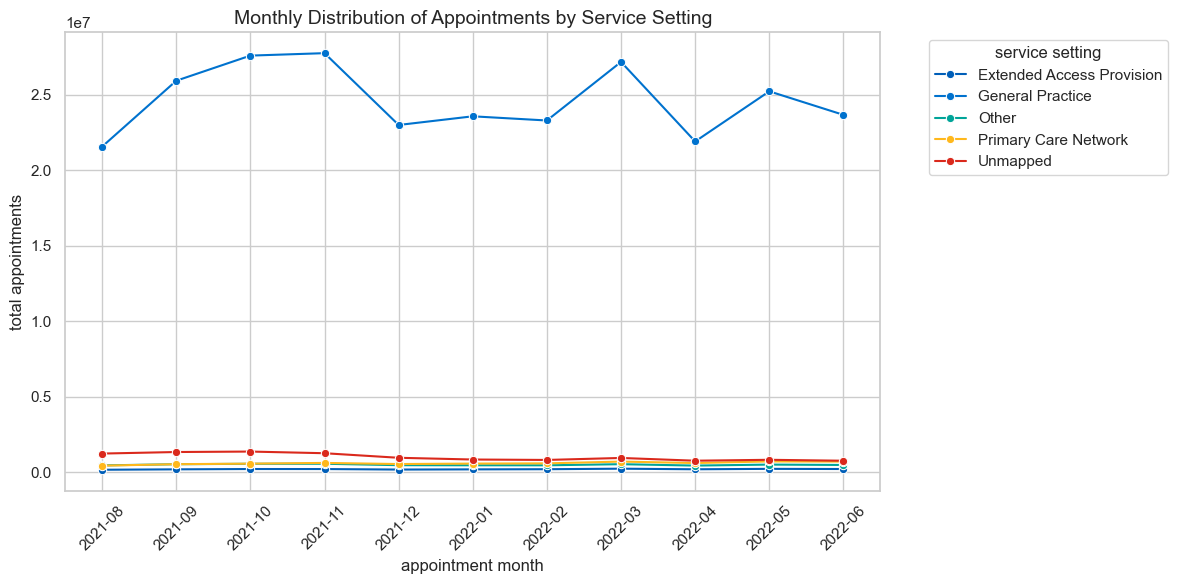

In [54]:
# Aggregate by appointment_month and service_setting
monthly_service_appointments = nc.groupby(['appointment_month', 'service_setting']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    monthly_service_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="service_setting",
    title="Monthly Distribution of Appointments by Service Setting",
)

**General Practice** consistently shows the highest utilisation among all service settings. Utilisation peaks are observed during October–November 2021 and again in March 2022.
These spikes likely correspond to:

Seasonal factors, such as increased respiratory and viral illnesses during colder months.

Policy and behavioural changes, including the lifting of COVID-19 restrictions in February 2022 and school reopening in September 2021, which may have increased healthcare demand due to higher social interaction and exposure.

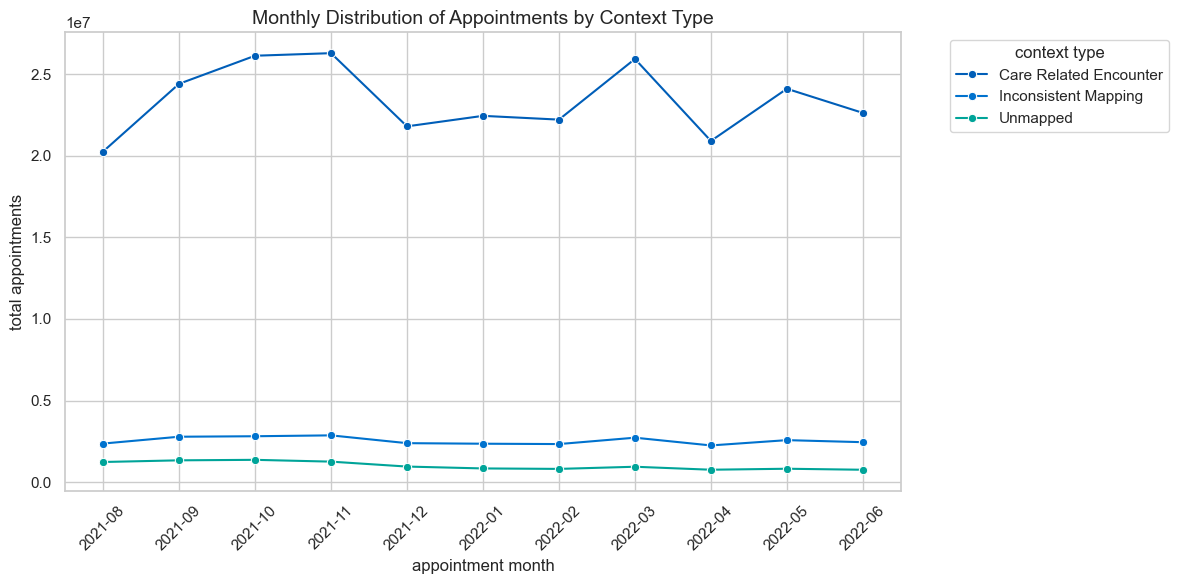

In [53]:
# Aggregate by appointment_month and context type
monthly_context_appointments = nc.groupby(['appointment_month', 'context_type']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    monthly_context_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="context_type",
    title="Monthly Distribution of Appointments by Context Type",
)

**Care Related Encounter** is consistently the most utilised contex type. The utilisation peaks are consitent with service setting trends.

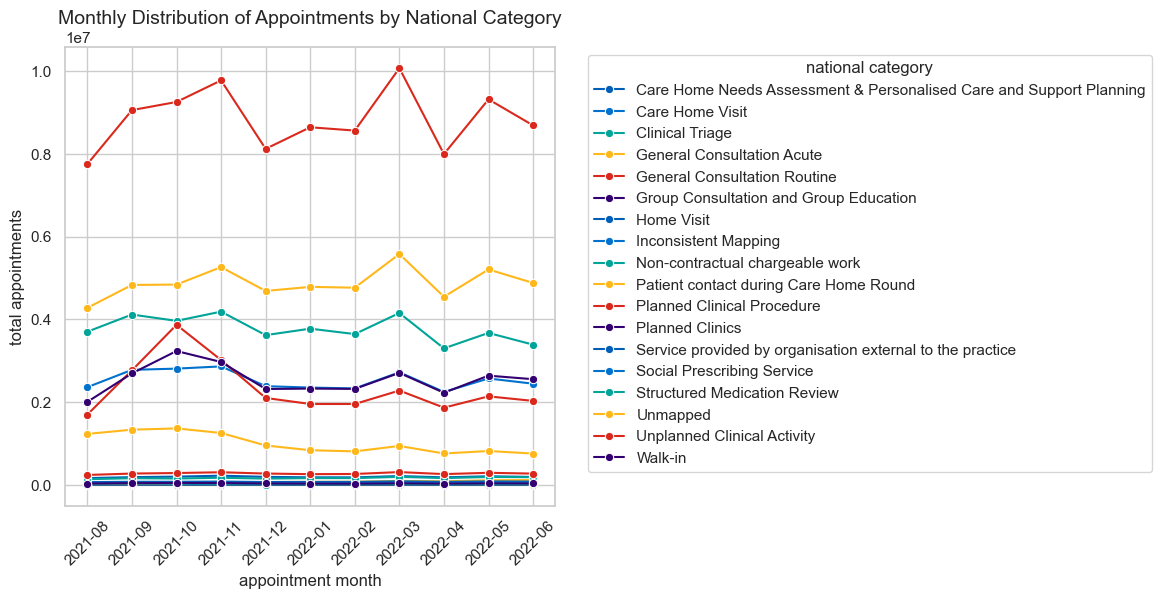

In [124]:
# Aggregate by appointment_month and national category
monthly_national_cat_appointments = nc.groupby(['appointment_month', 'national_category']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    monthly_national_cat_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="national_category",
    title="Monthly Distribution of Appointments by National Category",
)

Workload for **General Cosnultation Routine** tends to be high and variable, and shows an abrupt spike in March 2022 likely reflecting lifting of Covid restrictions.

**Unplanned clinical activity** has showed an **abrupt spike in October 2021**, likely reflecting a surge in demand after school re-opening rather than an operational inefficiency concern.

#### **Explore seasonal trends in total appointments per HCP type that could potentially indicate under or over-utilisation of NHS capacity.**

**Summer- June to August 2021**

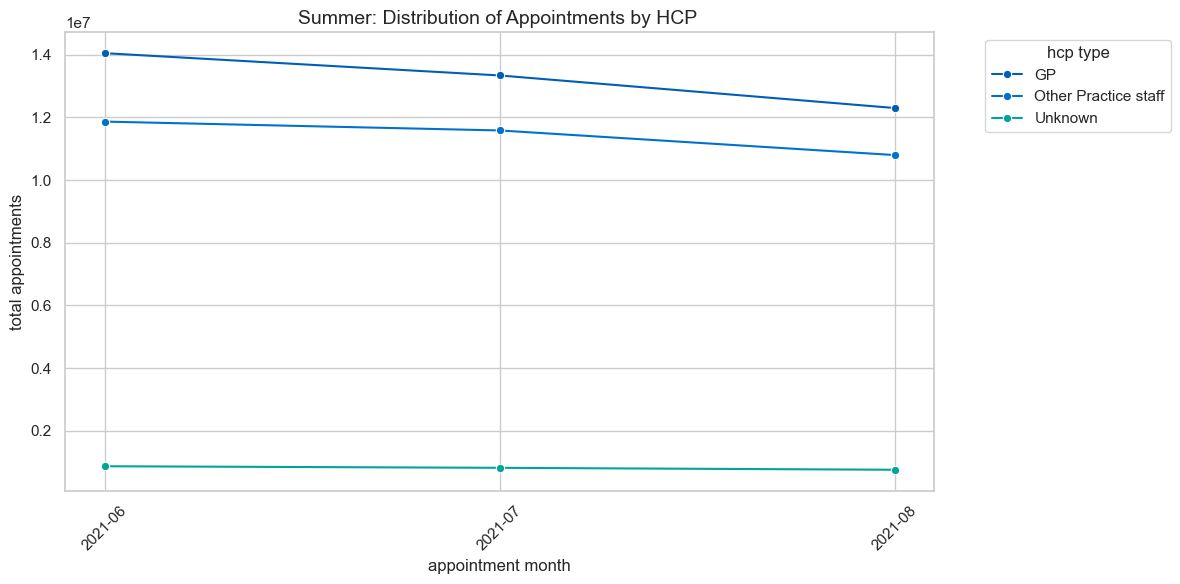

In [57]:
summer_ar = ar[
    (ar['appointment_month'] >= '2021-06') & 
    (ar['appointment_month'] <= '2021-08')
]

# Aggregate the data
summer_hcp_appointments = summer_ar.groupby(['appointment_month', 'hcp_type']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    summer_hcp_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="hcp_type",
    title="Summer: Distribution of Appointments by HCP",
)

**Autumn: September to November 2021**

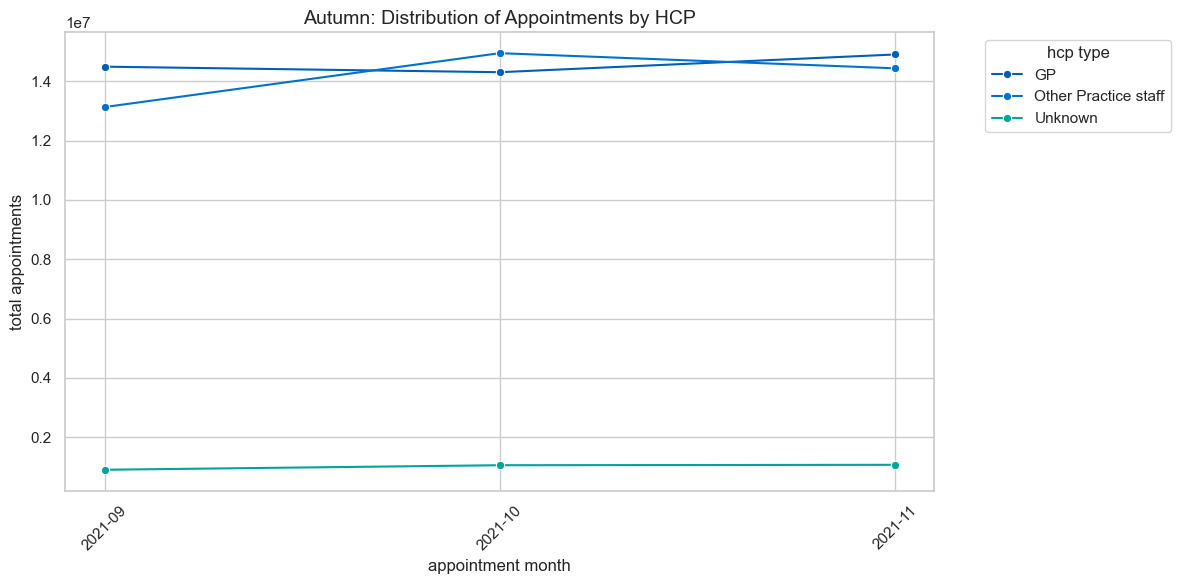

In [62]:
autumn_ar = ar[
    (ar['appointment_month'] >= '2021-09') & 
    (ar['appointment_month'] <= '2021-11')
]

# Aggregate the data
autumn_hcp_appointments = autumn_ar.groupby(['appointment_month', 'hcp_type']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    autumn_hcp_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="hcp_type",
    title="Autumn: Distribution of Appointments by HCP",
)

**Winter: December to February 2022**

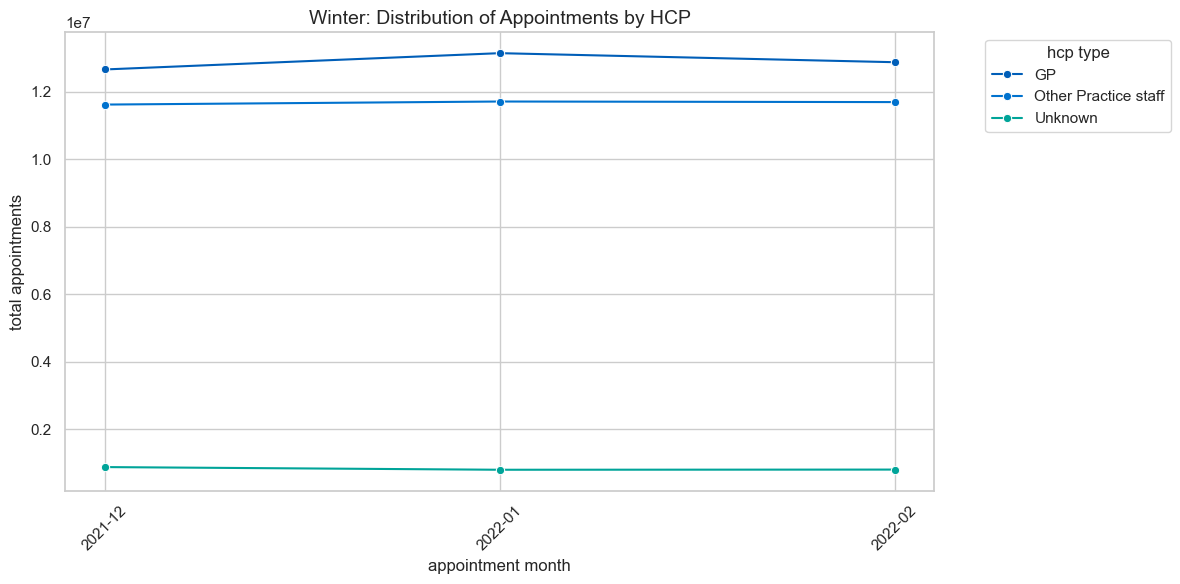

In [63]:
winter_ar = ar[
    (ar['appointment_month'] >= '2021-12') & 
    (ar['appointment_month'] <= '2022-02')
]

# Aggregate the data
winter_hcp_appointments = winter_ar.groupby(['appointment_month', 'hcp_type']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    winter_hcp_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="hcp_type",
    title="Winter: Distribution of Appointments by HCP",
)

**Spring: March to May 2022**

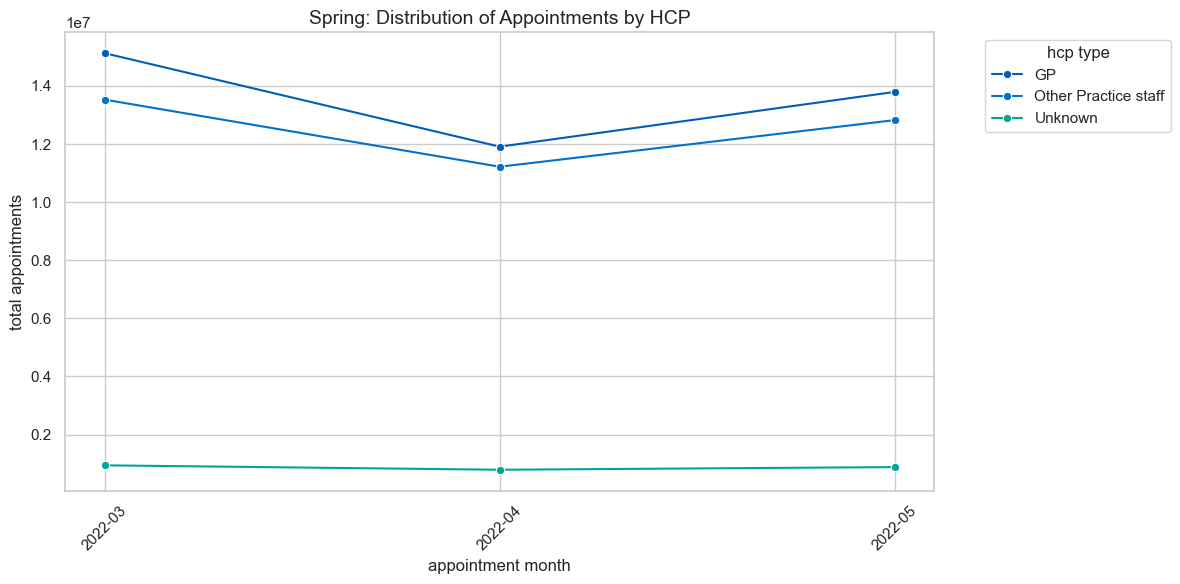

In [104]:
spring_ar = ar[
    (ar['appointment_month'] >= '2022-03') & 
    (ar['appointment_month'] <= '2022-05')
]

# Aggregate the data
spring_hcp_appointments = spring_ar.groupby(['appointment_month', 'hcp_type']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    spring_hcp_appointments,
    x="appointment_month",
    y="total_appointments",
    hue="hcp_type",
    title="Spring: Distribution of Appointments by HCP",
)

**Seasonal Trends in GP Appointments**

Across all seasons, total appointment volumes ranged between 11-15 million per month.

A decline in appointments is observed during winter and early spring, with the lowest number recorded in April 2022.

March 2022 marks a notable peak in GP appointments, potentially reflecting increased healthcare demand following the lifting of COVID-19 restrictions.

While some variation aligns with seasonal illness patterns, it is challenging to isolate the effect of seasonality from other influences such as pandemic recovery and policy changes.

#### **Change in waiting times between June 2021 to May 2022**

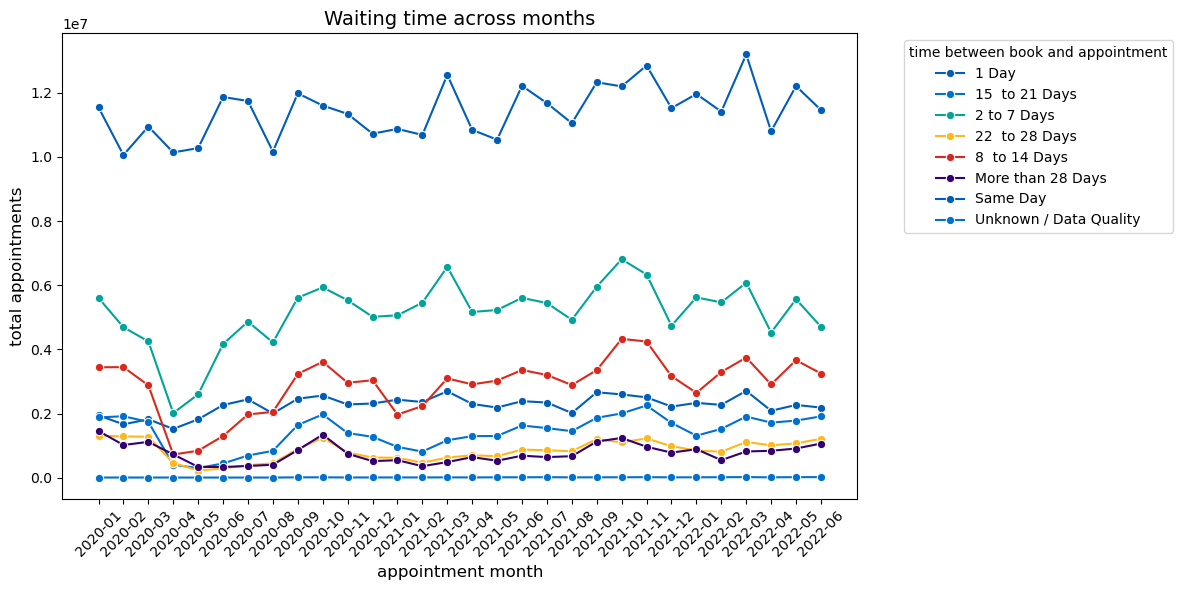

In [15]:
# Plot time_between_book_and_appointment across months
waiting_time = ar.groupby(['appointment_month', 'time_between_book_and_appointment']).agg(
    total_appointments=('count_of_appointments', 'sum')
).reset_index()

generate_standard_line_plot(
    waiting_time,
    x="appointment_month",
    y="total_appointments",
    hue="time_between_book_and_appointment",
    title="Waiting time across months",
)

Most appointments are delivered in less than 2 days. When system capacity seems to be available, more patients are moved to a shorter waiting time as seen April-June 2021 and Nov 2021 to Feb 2022. Overall number of appointments delivered within 2 days has increased over time.

**Visualise the DNA rate per month and ICB (region) in the ar dataset.**

Top 10 ICBs by DNA Rate (worst-performing ICBs in terms of missed appointments):
status_cat icb_ons_code  dna_rate
41            E54000062  5.842030
36            E54000057  5.710331
34            E54000055  5.601271
14            E54000029  5.581888
15            E54000030  5.472695
16            E54000031  5.089282
13            E54000028  5.042461
0             E54000008  5.011459
1             E54000010  4.833121
5             E54000018  4.673011

Lowest 10 ICBs by DNA Rate (best-performing ICBs in terms of missed appointments):
status_cat icb_ons_code  dna_rate
26            E54000043  3.295708
35            E54000056  3.275208
8             E54000023  3.248695
7             E54000022  3.229937
33            E54000054  3.213296
37            E54000058  3.043615
24            E54000041  2.997676
23            E54000040  2.968147
38            E54000059  2.965812
11            E54000026  2.693561


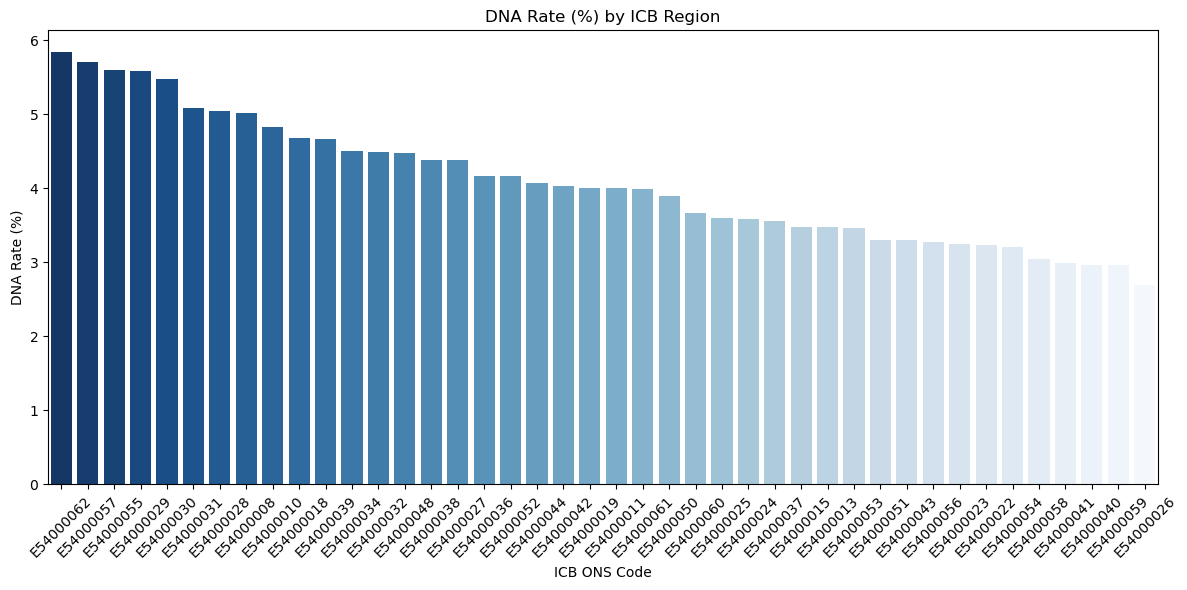

In [18]:
# --- 1. Clean appointment status ---
ar["appointment_status_clean"] = (
    ar["appointment_status"]
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

# --- 2. Map statuses to canonical groups ---
def map_status(s):
    if pd.isna(s):
        return "unknown"
    s = s.lower()
    if "attend" in s and "did not" not in s:
        return "attended"
    if "did not attend" in s or s == "dna":
        return "dna"
    if "unknown" in s or "data quality" in s:
        return "unknown"
    return s

ar["status_cat"] = ar["appointment_status_clean"].apply(map_status)

# --- 3. Aggregate counts by ICB and status ---
agg = (
    ar.groupby(["icb_ons_code", "status_cat"])["count_of_appointments"]
    .sum()
    .reset_index()
)

# --- 4. Pivot to get each status as a column ---
pivot = agg.pivot_table(
    index="icb_ons_code",
    columns="status_cat",
    values="count_of_appointments",
    fill_value=0
).reset_index()

# --- 5. Compute totals and DNA rate ---
pivot["total_appointments"] = pivot[["attended", "dna", "unknown"]].sum(axis=1)
pivot["dna_rate"] = (pivot["dna"] / pivot["total_appointments"]) * 100

# --- 6. Sort and display ---
pivot_sorted = pivot.sort_values("dna_rate", ascending=False)

print("Top 10 ICBs by DNA Rate (worst-performing ICBs in terms of missed appointments):")
print(pivot_sorted.head(10)[["icb_ons_code", "dna_rate"]])

print("\nLowest 10 ICBs by DNA Rate (best-performing ICBs in terms of missed appointments):")
print(pivot_sorted.tail(10)[["icb_ons_code", "dna_rate"]])

# --- 7. Optional: Plot ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=pivot_sorted,
    x="icb_ons_code",
    y="dna_rate",
    palette="Blues_r"
)
plt.title("DNA Rate (%) by ICB Region")
plt.xlabel("ICB ONS Code")
plt.ylabel("DNA Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There is substantial variation across ICBs: the top DNA rate is ~5.84%, while the lowest is ~2.69% — more than a twofold difference.

Interventions could be targeted at the higher-DNA ICBs (top list).

The ranking gives a prioritized list for deeper investigation: for example, E54000062 (NHS Black Country), E54000057 (NHS Greater Manchester), and E54000055 (NHS Birmingham and Solihull) should be focal points.

Regions such as E54000026 (NHS Mid and South Essex), E54000059 (NHS Northamptonshire)  and E54000040 (NHS Bath and North East Somerset, Swindon and Wiltshire) appear to manage attendance more effectively (or face fewer barriers) than others.

#### **Analyse public sentiment from Twitter data to uncover recurring themes about the NHS system that may influence attendance behaviour.**

In [32]:
tw["clean_text"] = tw["tweet_full_text"].apply(clean_tweet)

In [127]:
tw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
 10  clean_text               1174 non-null   object
dtypes: bool(2), int64(3), object(6)
memory usage: 85.0+ KB


Sentiment Distribution (%):
 sentiment_label
Positive    63.287905
Neutral     23.509370
Negative    13.202726
Name: proportion, dtype: float64


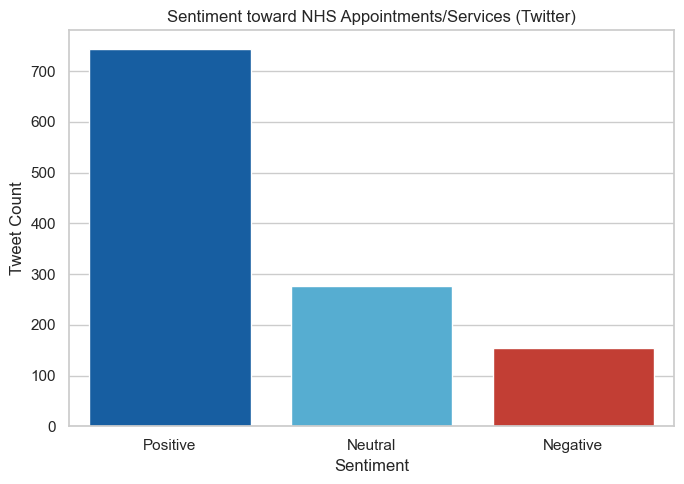

                     hashtag  count
0                #healthcare    844
1                    #health     86
2                        #ai     47
3                  #medicine     42
4                       #job     38
5                   #medical     35
6                  #strategy     31
7             #digitalhealth     31
8            #pharmaceutical     28
9                #medtwitter     27
10  #competitiveintelligence     25
11                #marketing     25
12                  #biotech     25
13                   #pharma     25
14                    #meded     24


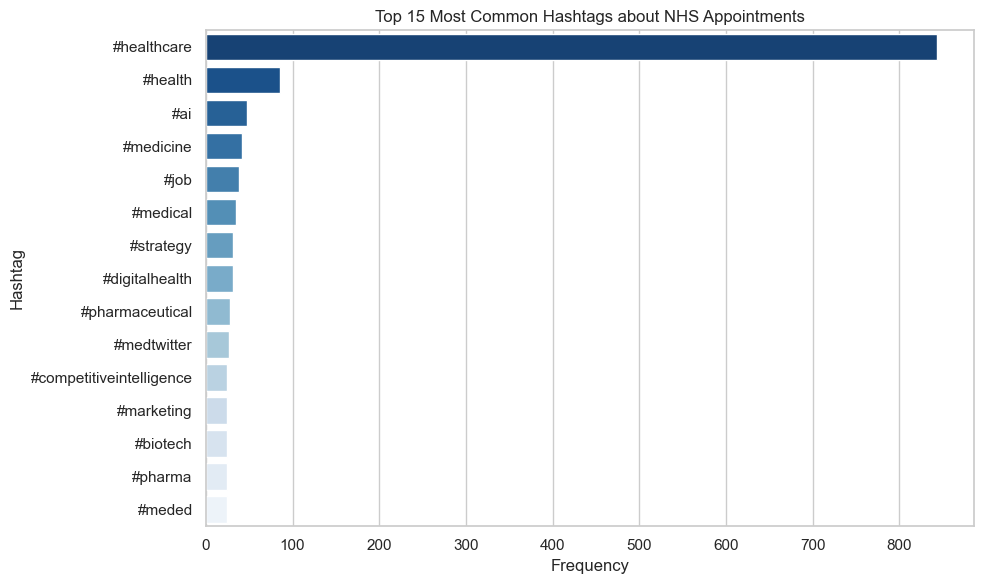

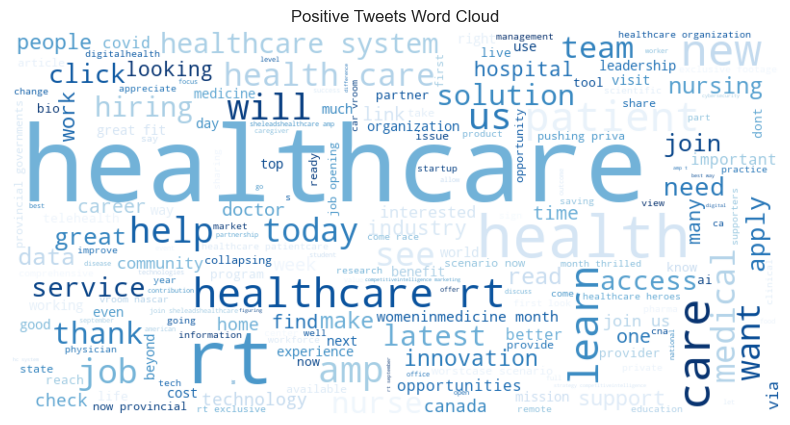

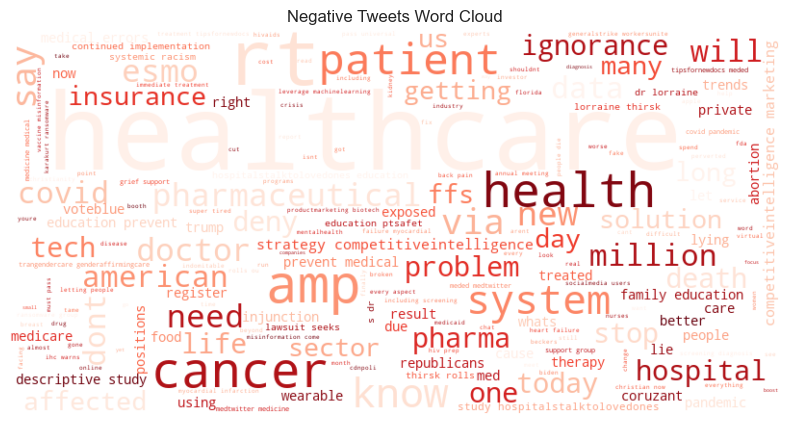

In [134]:
# Combine for an average sentiment score
tw["avg_sentiment"] = tw[["vader_score", "textblob_score"]].mean(axis=1)

# Categorize sentiment 
def label_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

tw["sentiment_label"] = tw["avg_sentiment"].apply(label_sentiment)

# Sentiment Summary 
sentiment_counts = tw["sentiment_label"].value_counts(normalize=True) * 100
print("Sentiment Distribution (%):\n", sentiment_counts)

plt.figure(figsize=(7,5))
# Changed 'df' to 'tw' to match the DataFrame that contains sentiment_label
sns.countplot(data=tw, x="sentiment_label", palette=["#005EB8","#41B6E6","#DA291C"])
plt.title("Sentiment toward NHS Appointments/Services (Twitter)")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.tight_layout()
plt.show()

tw["hashtags"] = tw["tweet_entities_hashtags"].astype(str).apply(extract_hashtags)

# Flatten the list of hashtags
# Changed 'df' to 'tw' to match the DataFrame that contains hashtags
all_hashtags = [h for sublist in tw["hashtags"] for h in sublist]
hashtag_counts = Counter(all_hashtags)

top_hashtags = pd.DataFrame(hashtag_counts.most_common(15), columns=["hashtag", "count"])
print(top_hashtags)

plt.figure(figsize=(10,6))
sns.barplot(data=top_hashtags, x="count", y="hashtag", palette="Blues_r")
plt.title("Top 15 Most Common Hashtags about NHS Appointments")
plt.xlabel("Frequency")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

# Word Cloud for Positive/Negative Sentiments
for sentiment, color in zip(["Positive", "Negative"], ["#41B6E6", "#DA291C"]):
    # Changed 'df' to 'tw' to match the DataFrame that contains sentiment_label and clean_text
    text = " ".join(tw.loc[tw["sentiment_label"] == sentiment, "clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white", colormap="Blues" if sentiment=="Positive" else "Reds").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{sentiment} Tweets Word Cloud")
    plt.show()

General sentiment towards NHS based on Twitter data is positive. Common hashtags do no indicate missed appointments and waiting time complaints in this dataset.

#### **Should the NHS start looking at increasing staff levels?**

Minimum date: 2020-01-01 00:00:00
Maximum date: 2022-06-01 00:00:00
  appointment_month hcp_type appointment_status appointment_mode  \
0        2021-08-01       GP           Attended     Face-to-Face   
1        2021-08-01       GP           Attended     Face-to-Face   
2        2021-08-01       GP           Attended     Face-to-Face   
3        2021-08-01       GP           Attended     Face-to-Face   
4        2021-08-01       GP           Attended     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                 507835  
1                    15  to 21 Days                 194726  
2                       2 to 7 Days                 959486  
3                    22  to 28 Days                 102111  
4                     8  to 14 Days                 398772  
  appointment_month  count_of_appointments  utilisation  \
0        2021-08-01               23852171     795072.4   
1        2021-09-01               28522

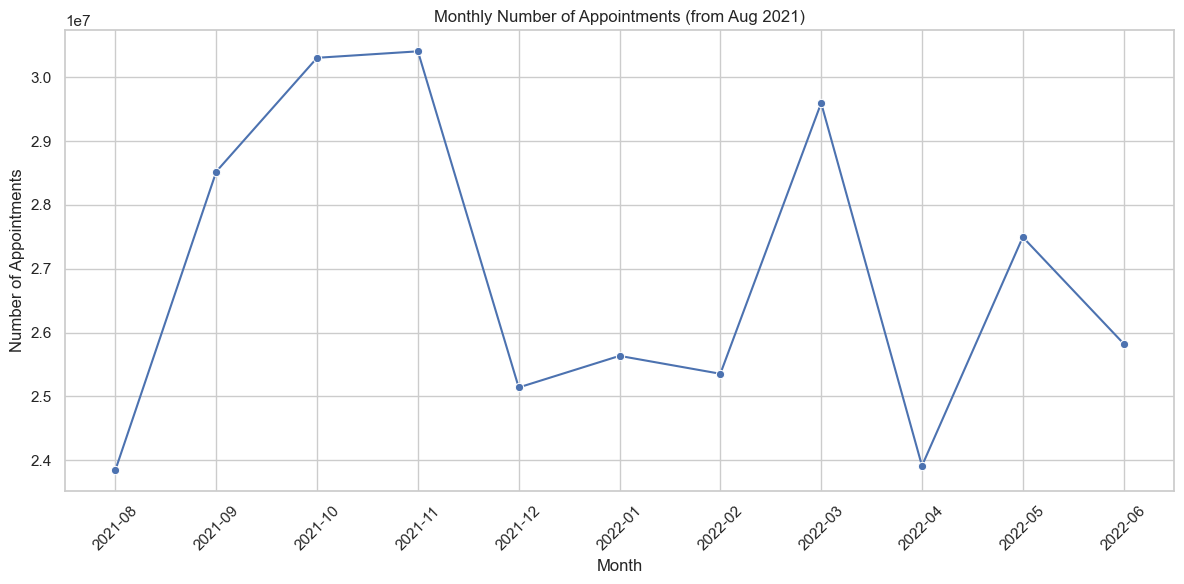

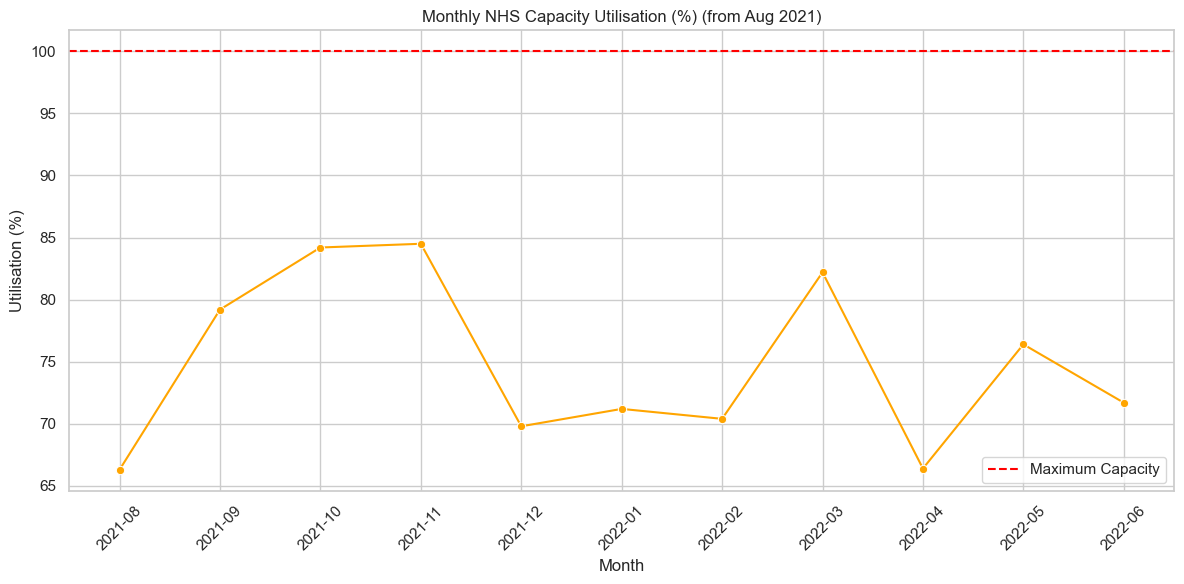

In [142]:
# Print the minimum and maximum dates
min_date = ar['appointment_month'].min()
max_date = ar['appointment_month'].max()
print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

# Step 1: Filter data from 2021-08 onwards
ar_filtered = ar[ar['appointment_month'] >= '2021-08']

# Step 2: Aggregate the filtered data
ar_agg = ar_filtered.groupby(
    ['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode', 'time_between_book_and_appointment']
)['count_of_appointments'].sum().reset_index()

print(ar_agg.head())

# Step 3: Determine average utilisation of services
ar_df = ar_filtered.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Calculate average daily utilisation
ar_df['utilisation'] = (ar_df['count_of_appointments'] / 30).round(1)

# NHS guideline for maximum daily appointments
nhs_capacity = 1200000
ar_df['capacity_utilisation_percent'] = ((ar_df['utilisation'] / nhs_capacity) * 100).round(1)

print(ar_df.head())

# Step 4: Convert appointment_month to string for plotting
ar_agg['appointment_month'] = ar_agg['appointment_month'].dt.strftime('%Y-%m')
ar_df['appointment_month'] = ar_df['appointment_month'].dt.strftime('%Y-%m')

# Step 5: Plot monthly visits
plt.figure(figsize=(12,6))
sns.lineplot(data=ar_df, x='appointment_month', y='count_of_appointments', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Number of Appointments (from Aug 2021)')
plt.ylabel('Number of Appointments')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

# Step 6: Plot monthly capacity utilisation
plt.figure(figsize=(12,6))
sns.lineplot(data=ar_df, x='appointment_month', y='capacity_utilisation_percent', marker='o', color='orange')
plt.xticks(rotation=45)
plt.title('Monthly NHS Capacity Utilisation (%) (from Aug 2021)')
plt.ylabel('Utilisation (%)')
plt.xlabel('Month')
plt.axhline(100, color='red', linestyle='--', label='Maximum Capacity')
plt.legend()
plt.tight_layout()
plt.show()

Utilisation of NHS capacity was upto 85% of planned capacity even at peak times. This reflects potential opportunities for operational efficiency improvements rather than hiring more staff.
While there could be a need for more frontline doctors and healthcare care workers in extremely busy clinics, it is difficult to quantify this requirement based on this data set.

#### **How do healthcare professionals differ over time?**

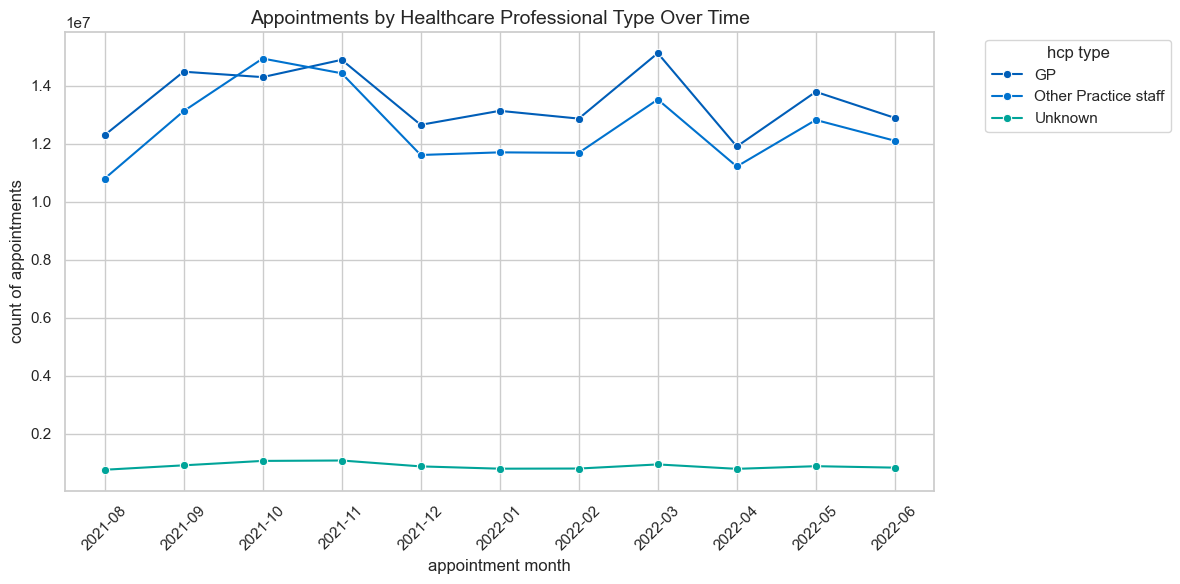

In [143]:
# Aggregate appointments by month and healthcare professional type
hcp_df = ar_filtered.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# Convert month to string for plotting
hcp_df['appointment_month'] = hcp_df['appointment_month'].dt.strftime('%Y-%m')

# Plot
generate_standard_line_plot(
    hcp_df,
    x="appointment_month",
    y="count_of_appointments",
    hue="hcp_type",
    title="Appointments by Healthcare Professional Type Over Time",
    marker='o'
)


Except in October 2021, GPs have been consistently handling more appointments than all other practice staff. 

Although full capacity is not utilised, GPs have been consistently at the forefront of handling the most appointments.

#### **Are there significant changes in whether or not visits are attended?**

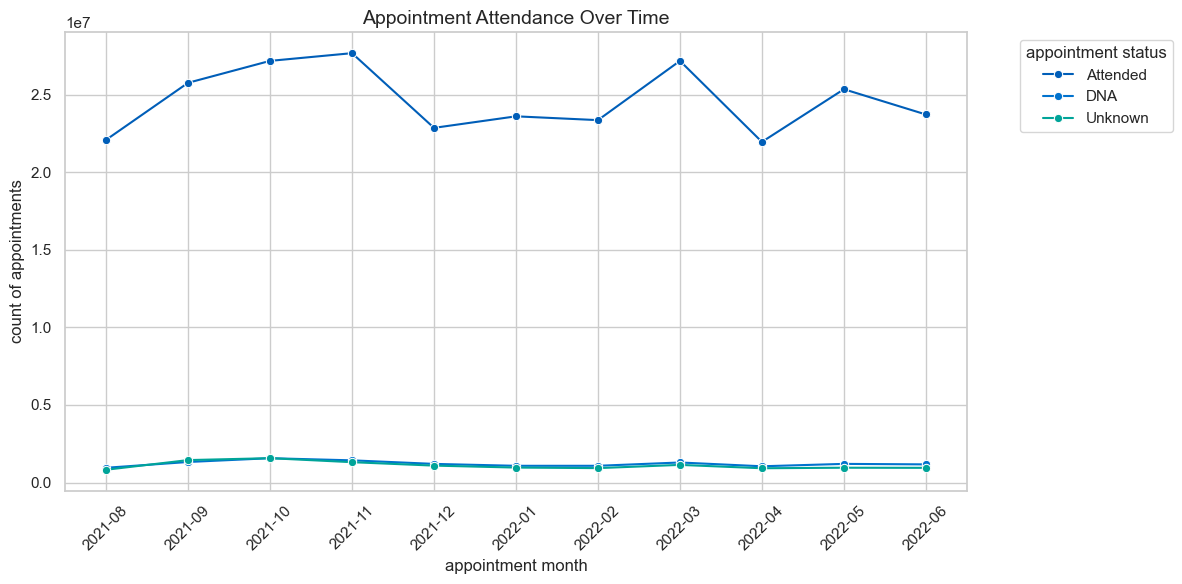

In [144]:
# Aggregate by month and appointment status (attended or not)
status_df = ar_filtered.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()
status_df['appointment_month'] = status_df['appointment_month'].dt.strftime('%Y-%m')

# Plot
generate_standard_line_plot(
    status_df,
    x="appointment_month",
    y="count_of_appointments",
    hue="appointment_status",
    title="Appointment Attendance Over Time",
    marker='o'
)

Proportion of DNAs has tracked with the total number of appointments over time, and has been consistent despite seasonal or circumstantial changes.

Appointment status is unknown for a large proportion of appointments (~4%, similar to % of DNA) and tracking this will help improve data quality and assessment of impact of operational improvements.

#### **Are there changes in terms of appointment type and the busiest months?**

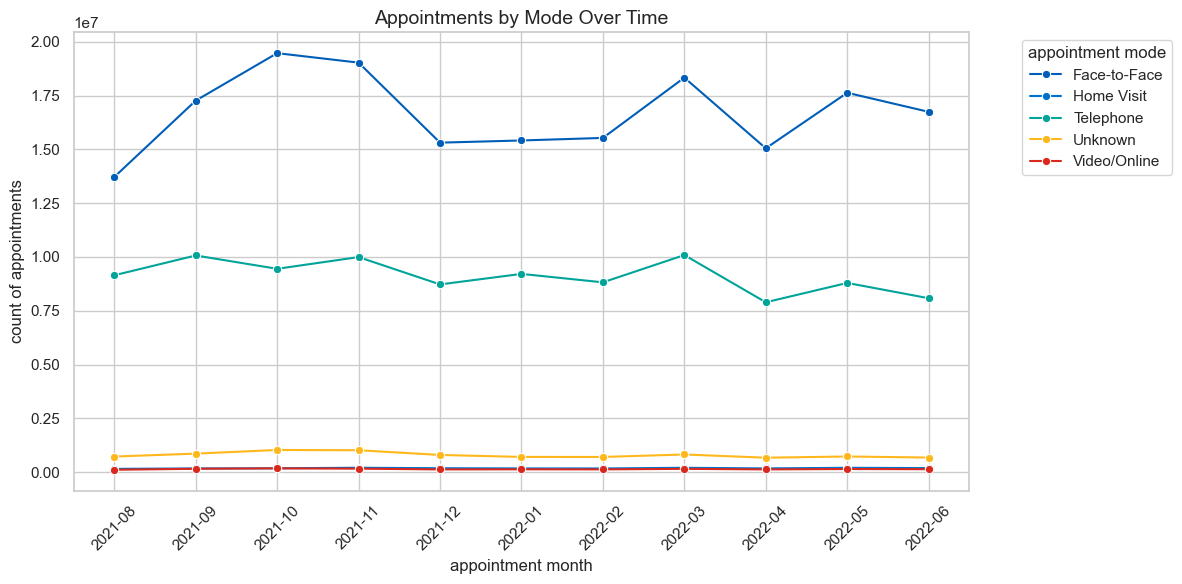

In [145]:
# Aggregate by month and appointment mode
mode_df = ar_filtered.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()
mode_df['appointment_month'] = mode_df['appointment_month'].dt.strftime('%Y-%m')

# Plot
generate_standard_line_plot(
    mode_df,
    x="appointment_month",
    y="count_of_appointments",
    hue="appointment_mode",
    title="Appointments by Mode Over Time",
    marker='o'
)

Compared to August 2021, number of face-to-face appointments has trended upwards while telephonic appointments have trended down.

Face-to-face appointments show a lot more variability over time, taking up higher workload in busy months, while other modes remain fairly stable over time. This presents an opportunity for other modes to absorb some of the workload spikes.

#### **Are there any trends in time between booking and appointment?**

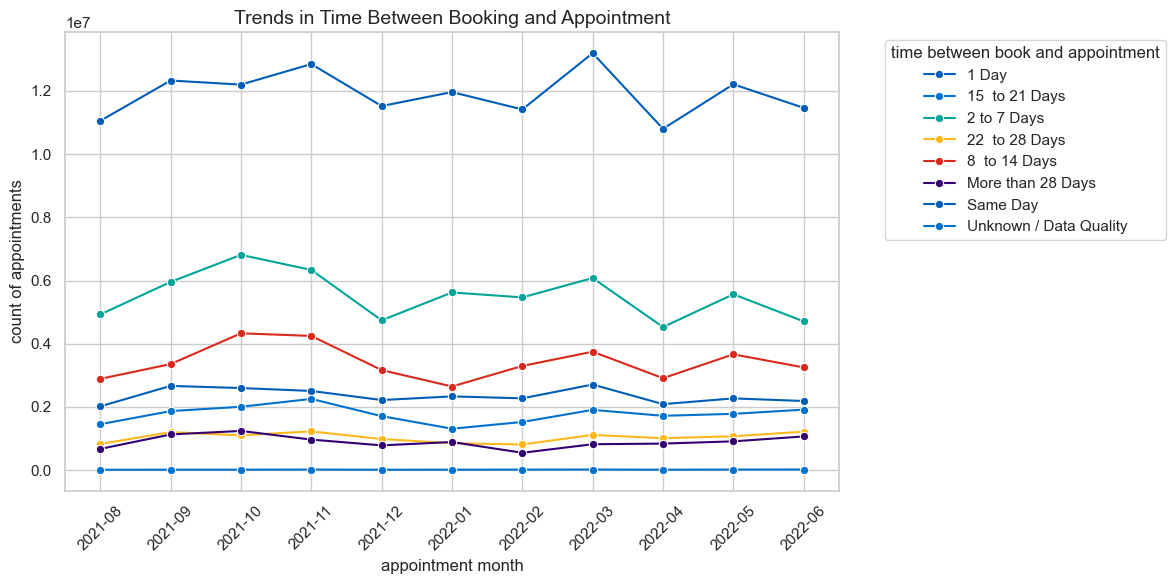

In [146]:
# Aggregate by month and time between booking and appointment
time_df = ar_filtered.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()
time_df['appointment_month'] = time_df['appointment_month'].dt.strftime('%Y-%m')

# Plot
generate_standard_line_plot(
    time_df,
    x="appointment_month",
    y="count_of_appointments",
    hue="time_between_book_and_appointment",
    title="Trends in Time Between Booking and Appointment",
    marker='o'
)

Most appointments are delivered in less than 2 days. When system capacity seems to be available, more patients are moved to a shorter waiting time as seen in Nov 2021 to Feb 2022. Overall number of appointments delivered within 2 days has increased over time.

#### **How do the various service settings compare?**

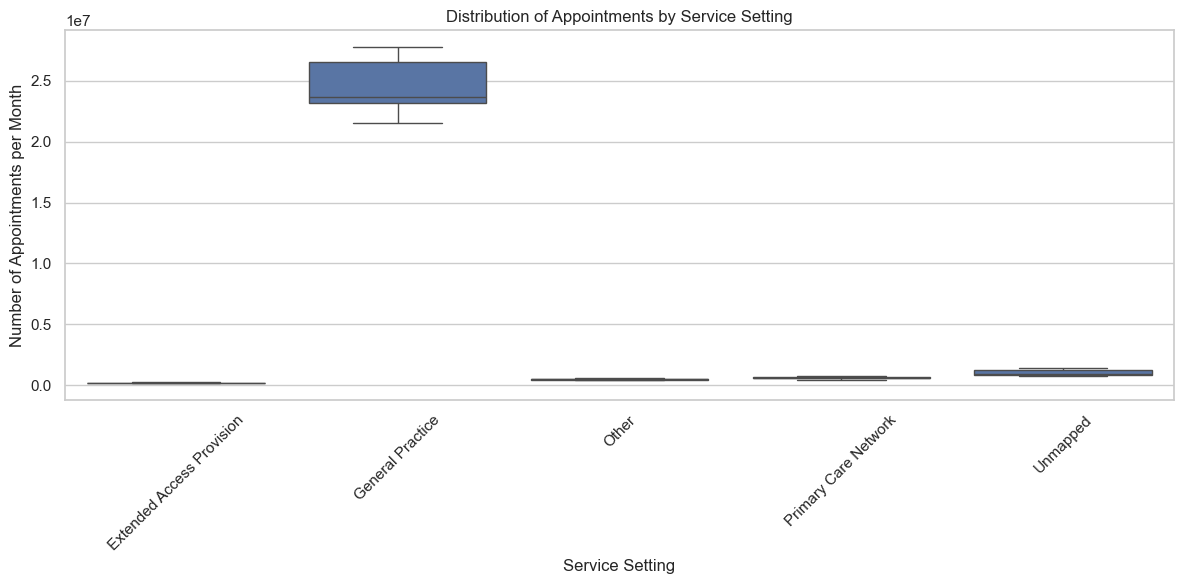

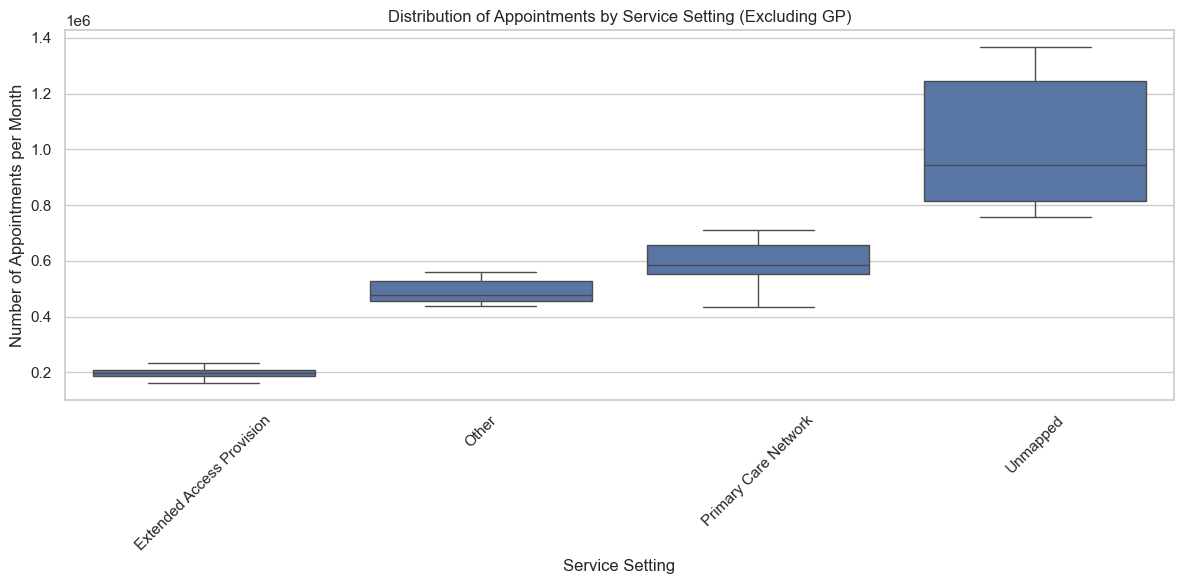

In [150]:
# Aggregate by month and service setting
service_df = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# Box plot for all service settings
plt.figure(figsize=(12,6))
sns.boxplot(data=service_df, x='service_setting', y='count_of_appointments')
plt.title('Distribution of Appointments by Service Setting')
plt.ylabel('Number of Appointments per Month')
plt.xlabel('Service Setting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('service_settings_boxplot_all.png')
plt.show()

# Exclude GP visits
service_excl_gp = service_df[service_df['service_setting'] != 'General Practice']

plt.figure(figsize=(12,6))
sns.boxplot(data=service_excl_gp, x='service_setting', y='count_of_appointments')
plt.title('Distribution of Appointments by Service Setting (Excluding GP)')
plt.ylabel('Number of Appointments per Month')
plt.xlabel('Service Setting')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('service_settings_boxplot_excl_gp.png')
plt.show()

GPs consistently handle most of the appointments and many appointments are unmapped.

#### **Summary of findings and recommendations based on the analysis.**

**Key findings:**

1. The NHS has adequate capacity, but imbalances in utilisation and appointment mode indicate efficiency improvement opportunities.

2. Reducing DNAs by even 1–2% could recover millions of appointments, improving access without additional staffing.

3. Regional targeting and mode flexibility (e.g., online/video options) can directly reduce missed appointments.

4. Improving appointment data quality and visibility is essential to accurately monitor operational performance and policy impact.


**NHS Operational Optimisation Recommendations:**

1. Diversify Appointment Modes: Promote digital and remote consultations to reduce travel barriers for attendance and absorb demand shocks.

2. Focus on High-DNA ICBs: Target Black Country, Birmingham & Solihull, Greater Manchester for improvement and leverage learning from low DNA ICBs.

3. Optimise Scheduling & Communication:
Increase lead time for bookings; reduce short-notice appointments. 
Improve reminder systems and self-service rebooking tools.

4. Strengthen Data Infrastructure:
Standardise appointment data entry and automate validation.

5. Continuous Performance Monitoring
Track utilisation and DNA rates by ICB, mode, and month.
Introduce performance dashboards for real-time utilisation tracking.

#### **Appendix**

#### **Additional exploratory analysis conducted as part of the asssignments**

#### Most popular service setting in NHS North West London from 1 January to 1 June 2022

                           number_of_records  total_appointments
service_setting                                                 
General Practice                        2104             4804239
Other                                   1318              152897
Primary Care Network                    1272              109840
Extended Access Provision               1090               98159
Unmapped                                 152              391106


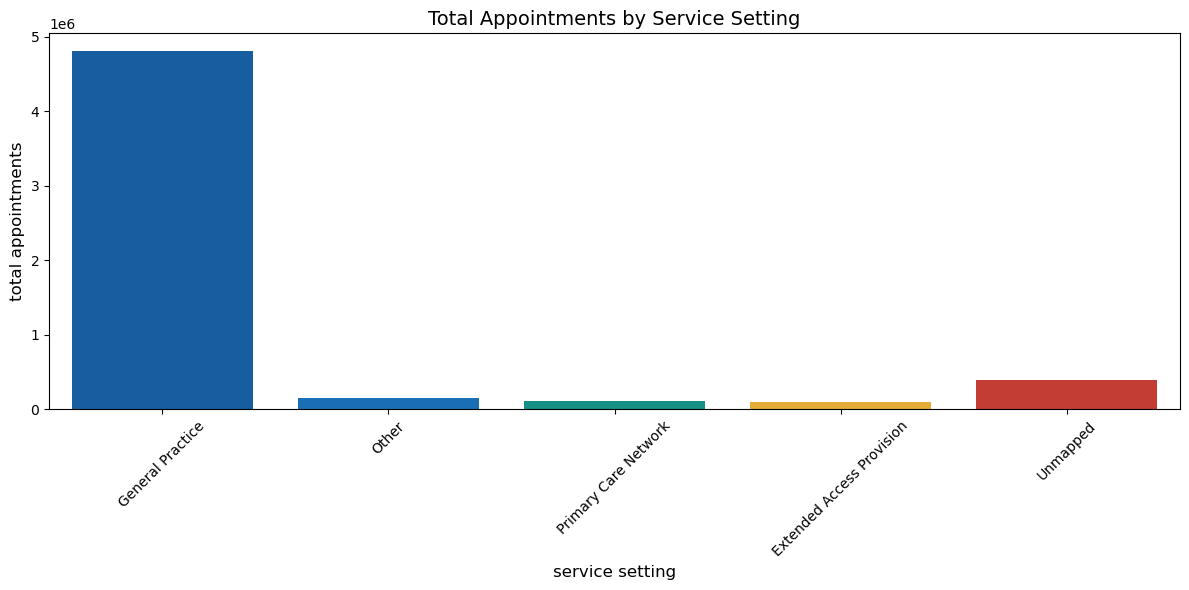

In [35]:
# Filter data for NHS North West London and the date range
filtered_nc1 = nc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
    (nc['appointment_date'] >= '2022-01-01') &
    (nc['appointment_date'] <= '2022-06-01')
]

# Group by service setting and calculate statistics
service_setting_summary = filtered_nc1.groupby('service_setting').agg(
    number_of_records=('service_setting', 'count'),
    total_appointments=('count_of_appointments', 'sum')
).sort_values('number_of_records', ascending=False)

print(service_setting_summary)

generate_standard_bar_chart(
    df=service_setting_summary,
    x="service_setting",
    y="total_appointments",
    title="Total Appointments by Service Setting",
    sort=False
)

**NHS North West London** is the busiest sub-ICB, and **General Practice** is the most accessed service in the period from 1 January to 1 June 2022.

#### Month with the highest number of appointments

In [37]:
# Number of appointments per month == sum of count_of_appointments by month.
monthly_appointments = nc.groupby('appointment_month').agg(
    total_appointments=('count_of_appointments', 'sum')
).sort_values('total_appointments', ascending=False)

print("Appointments by Month:")
print(monthly_appointments)

Appointments by Month:
                   total_appointments
appointment_month                    
2021-11                      30405070
2021-10                      30303834
2022-03                      29595038
2021-09                      28522501
2022-05                      27495508
2022-06                      25828078
2022-01                      25635474
2022-02                      25355260
2021-12                      25140776
2022-04                      23913060
2021-08                      23852171


**November 2021** had the highest number of appointments across NHS.